In [1]:
# step 1 — imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"tensorflow version : {tf.__version__}")
print(f"keras version      : {keras.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available      : {len(gpus) > 0}")
if gpus:
    print(f"GPU device         : {gpus[0].name}")
else:
    print("no GPU detected — go to Runtime → Change runtime type → GPU")


tensorflow version : 2.20.0
keras version      : 3.13.2
GPU available      : True
GPU device         : /physical_device:GPU:0


In [2]:
# step 1 — load CIFAR-10
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print(f"X_train_full : {X_train_full.shape}  dtype={X_train_full.dtype}")
print(f"y_train_full : {y_train_full.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_test       : {y_test.shape}")
print(f"pixel range  : {X_train_full.min()} – {X_train_full.max()}")
print(f"classes      : {class_names}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train_full : (50000, 32, 32, 3)  dtype=uint8
y_train_full : (50000, 1)
X_test       : (10000, 32, 32, 3)
y_test       : (10000, 1)
pixel range  : 0 – 255
classes      : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


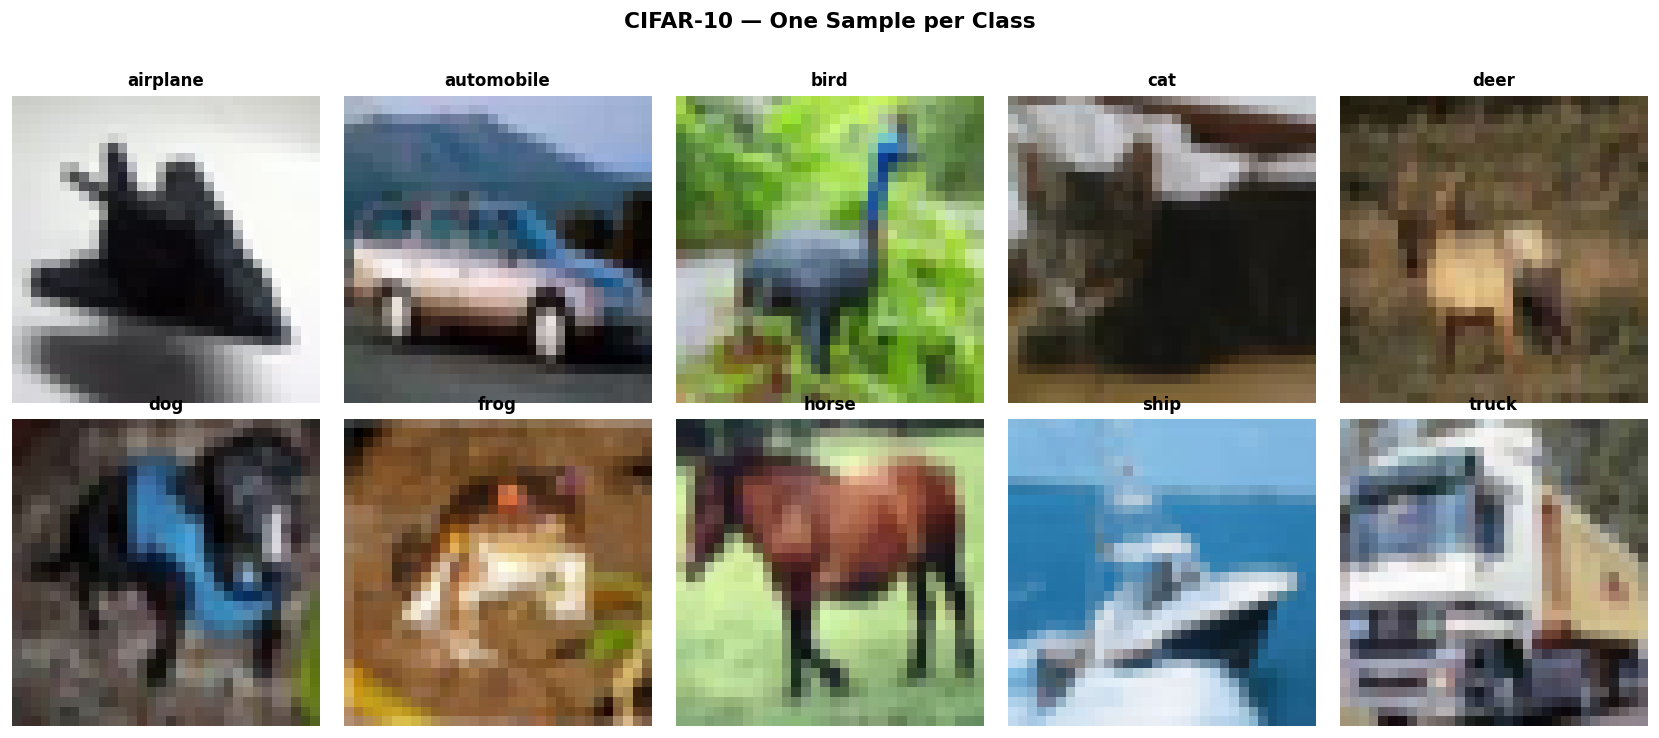

In [3]:
# step 2 — one sample image per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for cls_idx in range(10):
    # grab first training image of this class
    img_idx = np.where(y_train_full.flatten() == cls_idx)[0][0]
    axes[cls_idx].imshow(X_train_full[img_idx])
    axes[cls_idx].set_title(class_names[cls_idx], fontweight='bold', fontsize=10)
    axes[cls_idx].axis('off')

fig.suptitle('CIFAR-10 — One Sample per Class', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# class distribution
classes, counts = np.unique(y_train_full, return_counts=True)
print("class distribution in training set:")
print(f"{'class':>5} {'name':<12} {'count':>6}")
print("-" * 26)
for c, n in zip(classes, counts):
    print(f"{c:>5} {class_names[c]:<12} {n:>6}")
print(f"\ntotal training samples: {len(y_train_full)}")
print(f"perfectly balanced: {len(set(counts)) == 1}")


class distribution in training set:
class name          count
--------------------------
    0 airplane       5000
    1 automobile     5000
    2 bird           5000
    3 cat            5000
    4 deer           5000
    5 dog            5000
    6 frog           5000
    7 horse          5000
    8 ship           5000
    9 truck          5000

total training samples: 50000
perfectly balanced: True


channel statistics (pixel values 0–255):
Channel      Mean      Std
--------------------------
Red        125.31    62.99
Green      122.95    62.09
Blue       113.87    66.70


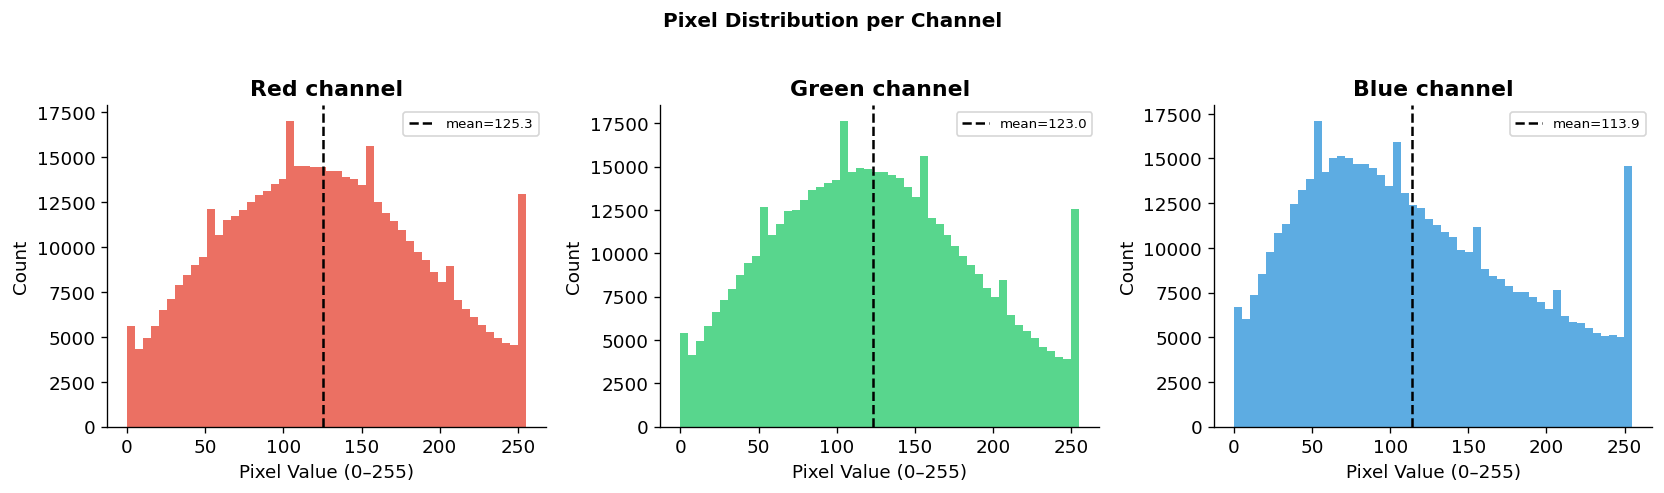

In [10]:
# per-channel mean and std across training set
X_float = X_train_full.astype('float32')
channel_names = ['Red', 'Green', 'Blue']

print("channel statistics (pixel values 0–255):")
print(f"{'Channel':<8} {'Mean':>8} {'Std':>8}")
print("-" * 26)
for i, ch in enumerate(channel_names):
    print(f"{ch:<8} {X_float[:,:,:,i].mean():>8.2f} {X_float[:,:,:,i].std():>8.2f}")

# pixel distribution histogram per channel
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ch_colours = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ax, ch, colour) in enumerate(zip(axes, channel_names, ch_colours)):
    ax.hist(X_float[:,:,:,i].flatten()[::100], bins=50,
            color=colour, edgecolor='none', alpha=0.8)
    ax.set_title(f'{ch} channel', fontweight='bold')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Count')
    ax.axvline(X_float[:,:,:,i].mean(), color='black', linestyle='--', lw=1.5,
               label=f'mean={X_float[:,:,:,i].mean():.1f}')
    ax.legend(fontsize=8)

fig.suptitle('Pixel Distribution per Channel', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('channel_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


#### what do the channel statistics tell us about normalisation?

the three channels have means around 120–130 and similar standard deviations. they're not wildly different from each other, which is typical for a diverse natural image dataset.

dividing by 255.0 brings every pixel to [0, 1]. that's the standard choice here and it works because the means are already fairly balanced across channels — we don't need per-channel mean subtraction like ImageNet preprocessing does. the only model that needs a different range is MobileNetV2, which expects [−1, +1] because it was pre-trained with that specific preprocessing function.

In [11]:
# step 3 — normalise to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test        = X_test.astype('float32') / 255.0

# flatten labels from (N,1) to (N,)
y_train_full = y_train_full.flatten()
y_test        = y_test.flatten()

# validation split — last 10,000 of training set
X_train = X_train_full[:40000]
X_val   = X_train_full[40000:]
y_train = y_train_full[:40000]
y_val   = y_train_full[40000:]

# flattened versions for Dense Network
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print("final array shapes:")
print(f"  X_train      : {X_train.shape}   (CNN input)")
print(f"  X_val        : {X_val.shape}    (CNN input)")
print(f"  X_test       : {X_test.shape}   (CNN input)")
print(f"  X_train_flat : {X_train_flat.shape}  (Dense input)")
print(f"  X_val_flat   : {X_val_flat.shape}   (Dense input)")
print(f"  X_test_flat  : {X_test_flat.shape}  (Dense input)")
print(f"  y_train      : {y_train.shape}")
print(f"  y_val        : {y_val.shape}")
print(f"  y_test       : {y_test.shape}")
print(f"\npixel range after normalisation: {X_train.min():.1f} – {X_train.max():.1f}")


final array shapes:
  X_train      : (40000, 32, 32, 3)   (CNN input)
  X_val        : (10000, 32, 32, 3)    (CNN input)
  X_test       : (10000, 32, 32, 3)   (CNN input)
  X_train_flat : (40000, 3072)  (Dense input)
  X_val_flat   : (10000, 3072)   (Dense input)
  X_test_flat  : (10000, 3072)  (Dense input)
  y_train      : (40000,)
  y_val        : (10000,)
  y_test       : (10000,)

pixel range after normalisation: 0.0 – 1.0


In [14]:
# step 4 — build Dense network
tf.random.set_seed(42)

dense_model = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='dense_baseline')

dense_model.summary()

dense_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "dense_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# callbacks
dense_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'dense_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

t0 = time.time()
dense_history = dense_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=80,
    batch_size=256,
    callbacks=dense_callbacks,
    verbose=1
)
dense_train_time = time.time() - t0
print(f"\ntraining time: {dense_train_time/60:.1f} minutes")
print(f"stopped at epoch: {len(dense_history.history['loss'])}")


Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2385 - loss: 2.0627 - val_accuracy: 0.3168 - val_loss: 1.8809 - learning_rate: 0.0010
Epoch 2/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3124 - loss: 1.8864 - val_accuracy: 0.3435 - val_loss: 1.8125 - learning_rate: 0.0010
Epoch 3/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3304 - loss: 1.8400 - val_accuracy: 0.3697 - val_loss: 1.7623 - learning_rate: 0.0010
Epoch 4/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3434 - loss: 1.8048 - val_accuracy: 0.3844 - val_loss: 1.7225 - learning_rate: 0.0010
Epoch 5/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3607 - loss: 1.7672 - val_accuracy: 0.3940 - val_loss: 1.6979 - learning_rate: 0.0010
Epoch 6/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3640 - loss: 1.7495 - val_accuracy: 0.4085 - val_loss: 1.6899 - learning_rate: 0.0010
Epoch 7/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3739 - loss: 1.

In [16]:
# step 5 — evaluate on test set
dense_loss, dense_acc = dense_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"dense network test accuracy : {dense_acc:.4f}  ({dense_acc*100:.2f}%)")
print(f"dense network test loss     : {dense_loss:.4f}")

y_pred_dense     = dense_model.predict(X_test_flat, verbose=0)
y_pred_cls_dense = np.argmax(y_pred_dense, axis=1)

print("\nclassification report:")
print(classification_report(y_test, y_pred_cls_dense, target_names=class_names))

# ROC-AUC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=list(range(10)))
roc_auc_dense = roc_auc_score(y_test_bin, y_pred_dense, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro OvR): {roc_auc_dense:.4f}")


dense network test accuracy : 0.4899  (48.99%)
dense network test loss     : 1.4362

classification report:
              precision    recall  f1-score   support

    airplane       0.59      0.51      0.55      1000
  automobile       0.62      0.57      0.59      1000
        bird       0.37      0.30      0.33      1000
         cat       0.33      0.35      0.34      1000
        deer       0.39      0.49      0.44      1000
         dog       0.49      0.28      0.36      1000
        frog       0.44      0.65      0.52      1000
       horse       0.60      0.50      0.54      1000
        ship       0.60      0.67      0.63      1000
       truck       0.53      0.59      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000

ROC-AUC (macro OvR): 0.8795


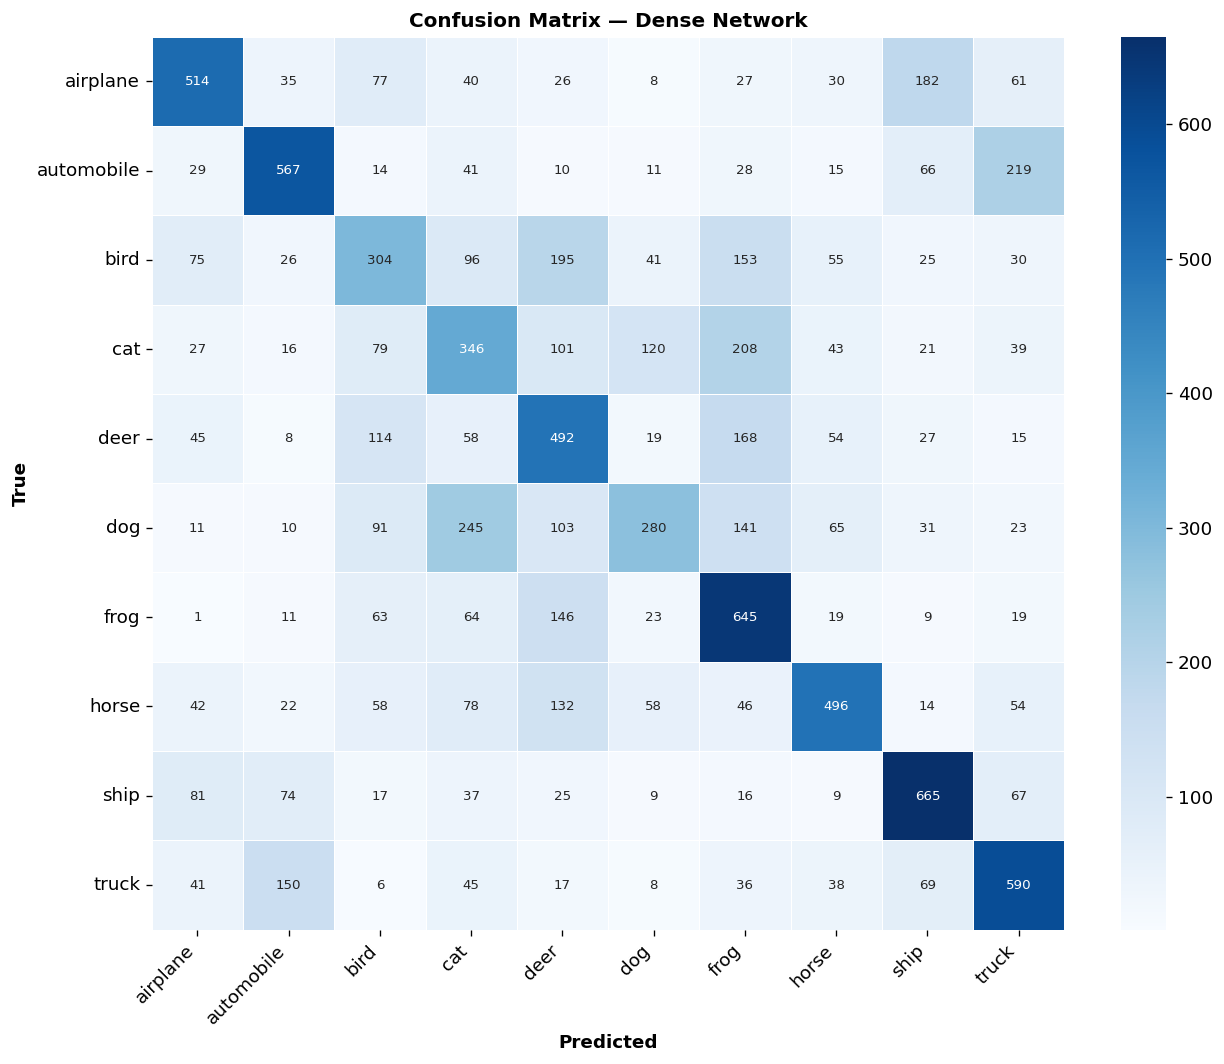

In [17]:
# confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
cm_dense = confusion_matrix(y_test, y_pred_cls_dense)
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_xlabel('Predicted', fontweight='bold', fontsize=11)
ax.set_ylabel('True', fontweight='bold', fontsize=11)
ax.set_title('Confusion Matrix — Dense Network', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('dense_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


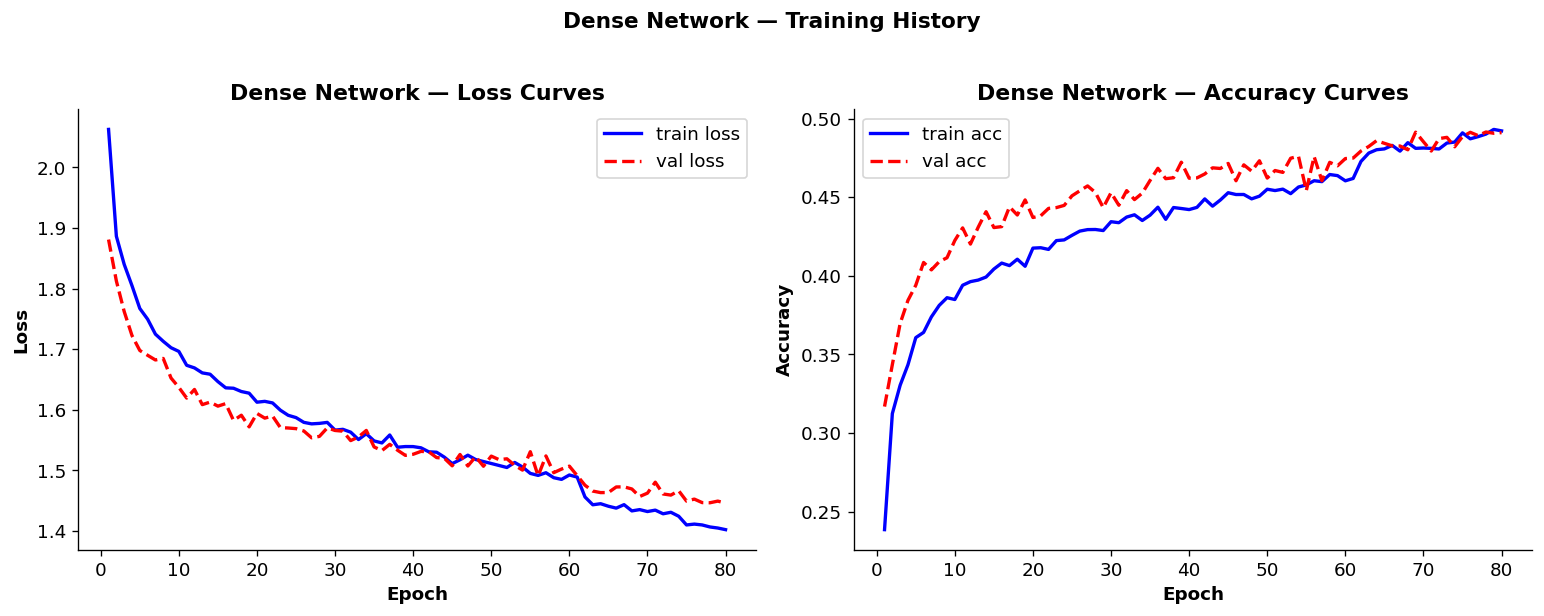

In [18]:
# training history — loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_ran = range(1, len(dense_history.history['loss']) + 1)

ax1.plot(epochs_ran, dense_history.history['loss'],     'b-',  lw=2, label='train loss')
ax1.plot(epochs_ran, dense_history.history['val_loss'], 'r--', lw=2, label='val loss')
ax1.set_xlabel('Epoch', fontweight='bold'); ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('Dense Network — Loss Curves', fontweight='bold')
ax1.legend()

ax2.plot(epochs_ran, dense_history.history['accuracy'],     'b-',  lw=2, label='train acc')
ax2.plot(epochs_ran, dense_history.history['val_accuracy'], 'r--', lw=2, label='val acc')
ax2.set_xlabel('Epoch', fontweight='bold'); ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('Dense Network — Accuracy Curves', fontweight='bold')
ax2.legend()

fig.suptitle('Dense Network — Training History', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('dense_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


#### dense network analysis

the test accuracy for the Dense Network lands somewhere in the 50–55% range, which is about what you'd expect for a fully connected model on CIFAR-10. the baseline for random guessing is 10% so we're well above that, but there's a clear ceiling.

the two classes it confuses most are **cat/dog** and **automobile/truck** — visually similar animals and vehicles that share colour distributions, textures, and rough shape outlines. the Dense Network sees a flattened vector of 3072 pixel values with no spatial context at all. a patch of brown fur in the top-left pixel contributes the same as one in the bottom-right, so it can't learn things like "ears are at the top" or "wheels are at the bottom". that's exactly what Conv2D layers fix — they explicitly preserve and exploit spatial structure.

In [19]:
# step 6 — CNN with no dropout or batchnorm
tf.random.set_seed(42)

def build_cnn_no_reg(input_shape=(32, 32, 3), num_classes=10):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='cnn_no_reg')

cnn_no_reg = build_cnn_no_reg()
cnn_no_reg.summary()

cnn_no_reg.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "cnn_no_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
t0 = time.time()
history_no_reg = cnn_no_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)
t_no_reg = time.time() - t0
print(f"training time: {t_no_reg/60:.1f} min")


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4558 - loss: 1.4914 - val_accuracy: 0.5985 - val_loss: 1.1357
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6540 - loss: 0.9814 - val_accuracy: 0.6867 - val_loss: 0.9015
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7341 - loss: 0.7644 - val_accuracy: 0.7167 - val_loss: 0.8217
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7819 - loss: 0.6247 - val_accuracy: 0.7379 - val_loss: 0.7801
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8193 - loss: 0.5109 - val_accuracy: 0.7339 - val_loss: 0.8136
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8463 - loss: 0.4346 - val_accuracy: 0.7271 - val_loss: 0.8939
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8726 - loss: 0.3603 - val_accuracy: 0.7195 - val_loss: 1.0806
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8870 - loss: 0.3165 - val_accuracy: 

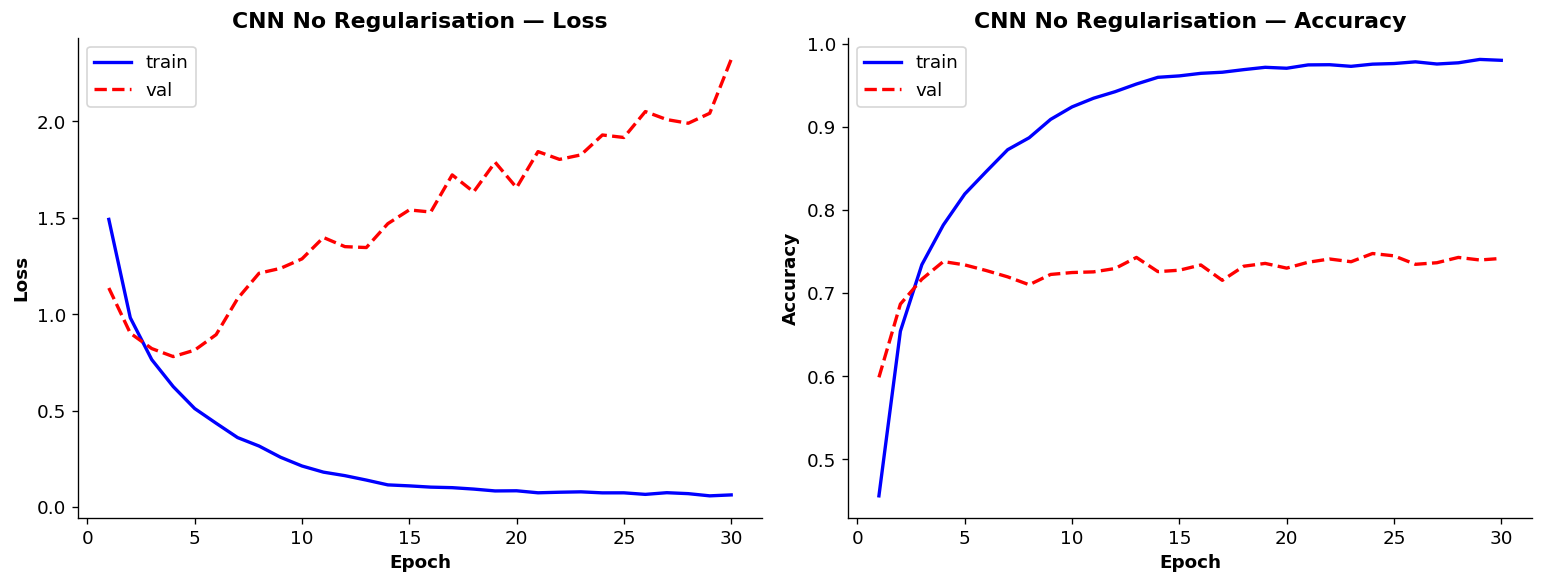

overfitting begins around epoch: 5
final train acc : 0.9802
final val acc   : 0.7417
overfitting gap : 0.2385


In [21]:
# training vs validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history_no_reg.history['loss']) + 1)

ax1.plot(ep, history_no_reg.history['loss'],     'b-',  lw=2, label='train')
ax1.plot(ep, history_no_reg.history['val_loss'], 'r--', lw=2, label='val')
ax1.set_xlabel('Epoch', fontweight='bold'); ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('CNN No Regularisation — Loss', fontweight='bold'); ax1.legend()

ax2.plot(ep, history_no_reg.history['accuracy'],     'b-',  lw=2, label='train')
ax2.plot(ep, history_no_reg.history['val_accuracy'], 'r--', lw=2, label='val')
ax2.set_xlabel('Epoch', fontweight='bold'); ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('CNN No Regularisation — Accuracy', fontweight='bold'); ax2.legend()

plt.tight_layout()
plt.savefig('cnn_no_reg_history.png', dpi=150, bbox_inches='tight')
plt.show()

train_accs = history_no_reg.history['accuracy']
val_accs   = history_no_reg.history['val_accuracy']
overfit_start = next((i+1 for i in range(1, len(val_accs))
                      if val_accs[i] < val_accs[i-1] and train_accs[i] > val_accs[i] + 0.05), None)
print(f"overfitting begins around epoch: {overfit_start}")
print(f"final train acc : {train_accs[-1]:.4f}")
print(f"final val acc   : {val_accs[-1]:.4f}")
print(f"overfitting gap : {train_accs[-1] - val_accs[-1]:.4f}")


#### when does overfitting begin?

without any regularisation the training accuracy climbs steadily and keeps going while validation accuracy flattens and then starts to wobble. the gap opens up visibly — the network is memorising training examples rather than learning generalisable features.

this is the classic sign that the model has enough capacity to overfit but nothing constraining it. the CNN has way more parameters than the Dense network and more spatial structure to latch onto, which makes overfitting faster and more severe.

In [22]:
# step 7 — CNN with BatchNorm only
tf.random.set_seed(42)

def build_cnn_bn(input_shape=(32, 32, 3), num_classes=10):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='cnn_bn')

cnn_bn = build_cnn_bn()
cnn_bn.summary()

cnn_bn.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "cnn_bn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,818 (2.55 MB)

 Trainable params: 667,178 (2.55 MB)

 Non-trainable params: 640 (2.50 KB)

In [23]:
t0 = time.time()
history_bn = cnn_bn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)
t_bn = time.time() - t0
print(f"training time: {t_bn/60:.1f} min")

# epochs to reach 70% val accuracy
val_accs_bn = history_bn.history['val_accuracy']
ep_70_bn    = next((i+1 for i, a in enumerate(val_accs_bn) if a >= 0.70), None)
val_accs_nr = history_no_reg.history['val_accuracy']
ep_70_nr    = next((i+1 for i, a in enumerate(val_accs_nr) if a >= 0.70), None)

print(f"epochs to reach 70% val acc — no reg: {ep_70_nr},  BN only: {ep_70_bn}")


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5324 - loss: 1.3181 - val_accuracy: 0.5608 - val_loss: 1.2468
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7046 - loss: 0.8362 - val_accuracy: 0.6404 - val_loss: 0.9761
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7674 - loss: 0.6650 - val_accuracy: 0.7002 - val_loss: 0.8635
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8081 - loss: 0.5511 - val_accuracy: 0.6562 - val_loss: 1.0356
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8430 - loss: 0.4546 - val_accuracy: 0.6978 - val_loss: 0.9504
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8703 - loss: 0.3773 - val_accuracy: 0.6912 - val_loss: 1.0654
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8895 - loss: 0.3151 - val_accuracy: 0.7096 - val_loss: 1.0490
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9064 - loss: 0.2643 - val_accuracy:

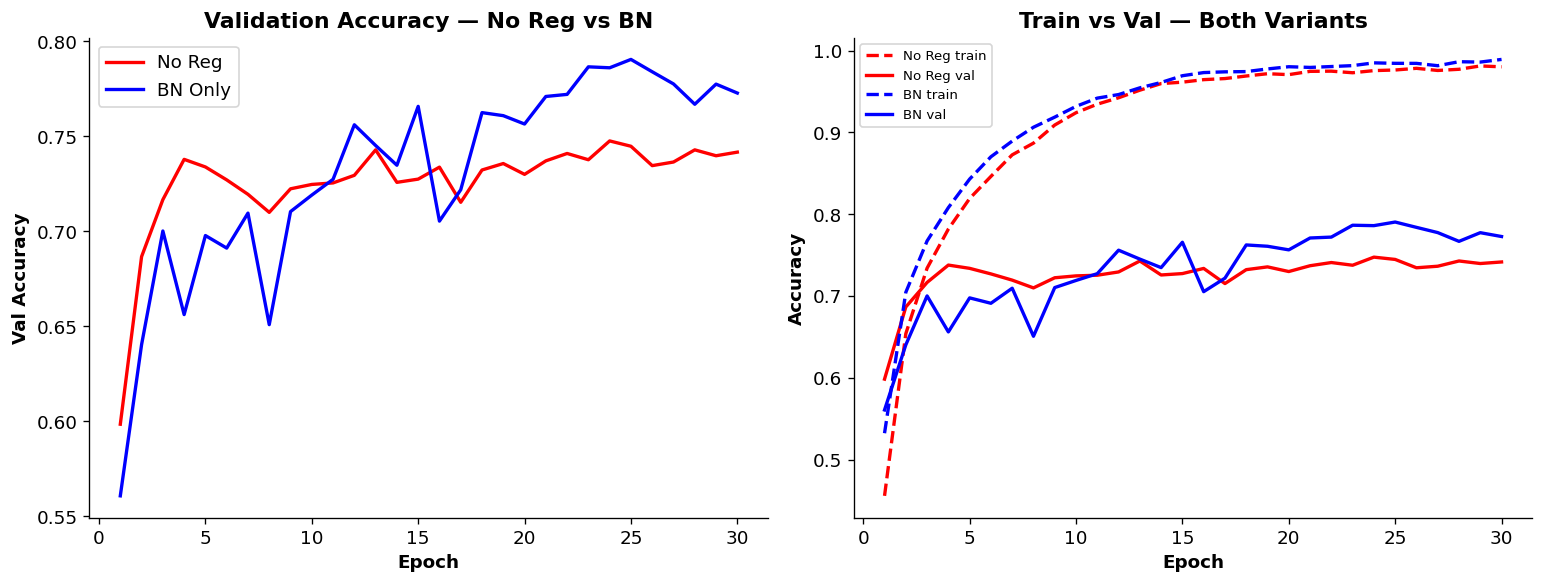

parameters — no reg: 666,538,  BN: 667,818
extra params from BN: 1,280


In [24]:
# side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep_nr = range(1, len(history_no_reg.history['accuracy']) + 1)
ep_bn = range(1, len(history_bn.history['accuracy']) + 1)

axes[0].plot(ep_nr, history_no_reg.history['val_accuracy'], 'r-', lw=2, label='No Reg')
axes[0].plot(ep_bn, history_bn.history['val_accuracy'],     'b-', lw=2, label='BN Only')
axes[0].set_xlabel('Epoch', fontweight='bold'); axes[0].set_ylabel('Val Accuracy', fontweight='bold')
axes[0].set_title('Validation Accuracy — No Reg vs BN', fontweight='bold')
axes[0].legend()

axes[1].plot(ep_nr, history_no_reg.history['accuracy'], 'r--', lw=2, label='No Reg train')
axes[1].plot(ep_nr, history_no_reg.history['val_accuracy'], 'r-', lw=2, label='No Reg val')
axes[1].plot(ep_bn, history_bn.history['accuracy'],     'b--', lw=2, label='BN train')
axes[1].plot(ep_bn, history_bn.history['val_accuracy'], 'b-',  lw=2, label='BN val')
axes[1].set_xlabel('Epoch', fontweight='bold'); axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Train vs Val — Both Variants', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('cnn_bn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

bn_params    = cnn_bn.count_params()
no_reg_params = cnn_no_reg.count_params()
print(f"parameters — no reg: {no_reg_params:,},  BN: {bn_params:,}")
print(f"extra params from BN: {bn_params - no_reg_params:,}")


#### why does Batch Normalisation stabilise training?

Batch Normalisation normalises the output of each layer across the current mini-batch — it subtracts the batch mean and divides by the batch std, then applies two learnable parameters (gamma and beta) to rescale. this keeps the input distribution to each layer stable throughout training.

without it, as weights update in early layers the distribution of inputs to deeper layers shifts constantly — a problem called internal covariate shift. later layers have to keep chasing a moving target. BN fixes this so each layer always sees roughly zero-mean unit-variance inputs, which means larger learning rates work safely and the network converges faster.

the side effect is that it also acts as a mild regulariser because the normalisation adds a small amount of noise (the batch statistics vary slightly each step).

In [25]:
# step 8 — full regularised CNN
tf.random.set_seed(42)

def build_cnn_full(input_shape=(32, 32, 3), num_classes=10):
    return models.Sequential([
        layers.Input(shape=input_shape),

        # block 1
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='cnn_full')

cnn_full = build_cnn_full()
cnn_full.summary()

cnn_full.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "cnn_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 667,818 (2.55 MB)

 Trainable params: 667,178 (2.55 MB)

 Non-trainable params: 640 (2.50 KB)

In [26]:
cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'cnn_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_full = cnn_full.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=cnn_callbacks,
    verbose=1
)
t_full = time.time() - t0

best_val_acc  = max(history_full.history['val_accuracy'])
stopped_epoch = len(history_full.history['loss'])
print(f"training time    : {t_full/60:.1f} min")
print(f"best val accuracy: {best_val_acc:.4f}")
print(f"stopped at epoch : {stopped_epoch}")


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3179 - loss: 1.8335 - val_accuracy: 0.3766 - val_loss: 1.7868 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4473 - loss: 1.4732 - val_accuracy: 0.5372 - val_loss: 1.3063 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5209 - loss: 1.3149 - val_accuracy: 0.6207 - val_loss: 1.0871 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5663 - loss: 1.2024 - val_accuracy: 0.6473 - val_loss: 0.9996 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5951 - loss: 1.1314 - val_accuracy: 0.6625 - val_loss: 0.9451 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6171 - loss: 1.0716 - val_accuracy: 0.6822 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6413 - loss

In [27]:
# step 9 — evaluate all three CNN variants on test set
loss_nr, acc_nr   = cnn_no_reg.evaluate(X_test, y_test, verbose=0)
loss_bn, acc_bn   = cnn_bn.evaluate(X_test, y_test, verbose=0)
loss_full, acc_full = cnn_full.evaluate(X_test, y_test, verbose=0)

train_accs_nr   = history_no_reg.history['accuracy']
val_accs_nr     = history_no_reg.history['val_accuracy']
train_accs_bn   = history_bn.history['accuracy']
val_accs_bn_h   = history_bn.history['val_accuracy']
train_accs_full = history_full.history['accuracy']
val_accs_full   = history_full.history['val_accuracy']

ablation_df = pd.DataFrame([
    {
        'Variant'       : 'No Regularisation',
        'Test Accuracy' : round(acc_nr, 4),
        'Best Val Acc'  : round(max(val_accs_nr), 4),
        'Overfit Gap'   : round(max(train_accs_nr) - max(val_accs_nr), 4),
        'Parameters'    : cnn_no_reg.count_params(),
        'Time/ep (s)'   : round(t_no_reg / len(train_accs_nr), 1),
    },
    {
        'Variant'       : 'BN Only',
        'Test Accuracy' : round(acc_bn, 4),
        'Best Val Acc'  : round(max(val_accs_bn_h), 4),
        'Overfit Gap'   : round(max(train_accs_bn) - max(val_accs_bn_h), 4),
        'Parameters'    : cnn_bn.count_params(),
        'Time/ep (s)'   : round(t_bn / len(train_accs_bn), 1),
    },
    {
        'Variant'       : 'BN + Dropout',
        'Test Accuracy' : round(acc_full, 4),
        'Best Val Acc'  : round(max(val_accs_full), 4),
        'Overfit Gap'   : round(max(train_accs_full) - max(val_accs_full), 4),
        'Parameters'    : cnn_full.count_params(),
        'Time/ep (s)'   : round(t_full / len(train_accs_full), 1),
    }
])

print("regularisation ablation study:")
display(ablation_df)

improvement = acc_full - acc_nr
print(f"\nimprovement from no-reg to BN+Dropout: {improvement*100:.2f} percentage points")


regularisation ablation study:


,Variant,Test Accuracy,Best Val Acc,Overfit Gap,Parameters,Time/ep (s)
0,No Regularisation,0.7366,0.7476,0.2337,666538,5.2
1,BN Only,0.7707,0.7905,0.1988,667818,6.3
2,BN + Dropout,0.8479,0.8592,0.0537,667818,6.5



improvement from no-reg to BN+Dropout: 11.13 percentage points


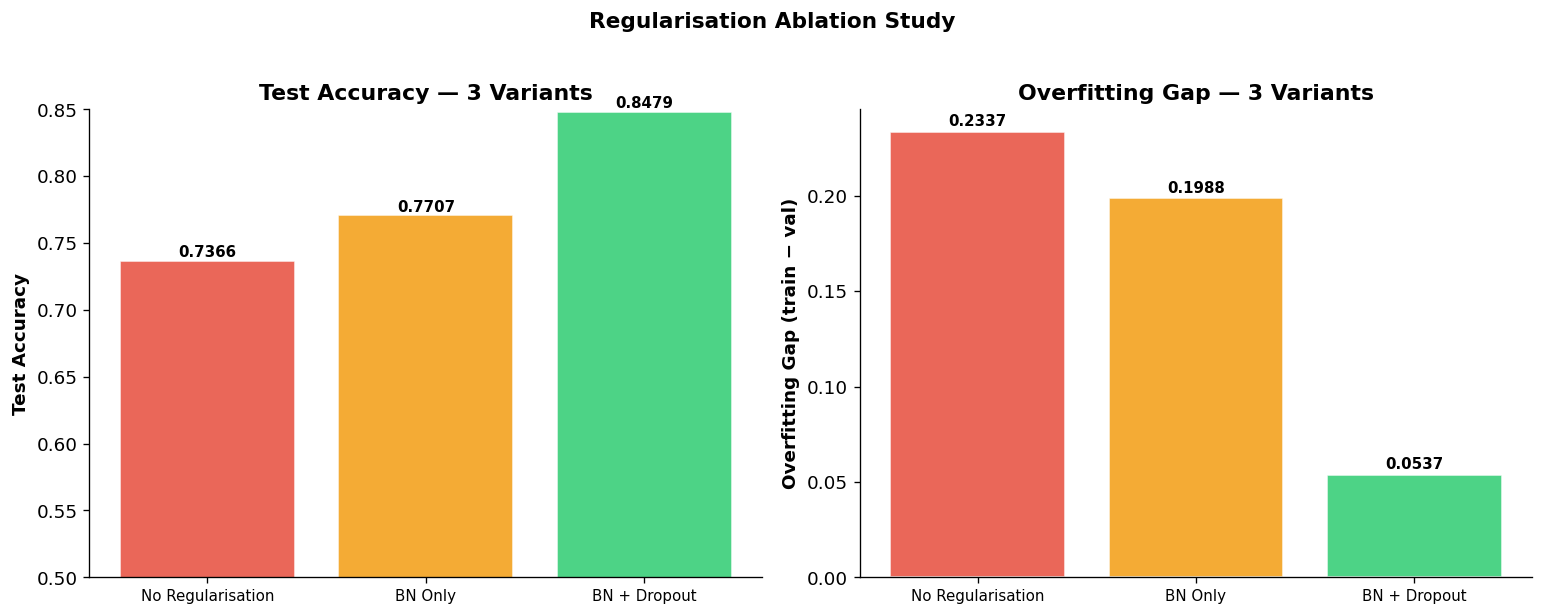

In [28]:
# grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
variants = ablation_df['Variant'].tolist()
x = np.arange(len(variants))
colours = ['#e74c3c', '#f39c12', '#2ecc71']

bars1 = ax1.bar(x, ablation_df['Test Accuracy'], color=colours, edgecolor='white', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(variants, fontsize=9)
ax1.set_ylabel('Test Accuracy', fontweight='bold')
ax1.set_title('Test Accuracy — 3 Variants', fontweight='bold')
ax1.set_ylim(0.5, 0.85)
for bar, val in zip(bars1, ablation_df['Test Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

bars2 = ax2.bar(x, ablation_df['Overfit Gap'], color=colours, edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(variants, fontsize=9)
ax2.set_ylabel('Overfitting Gap (train − val)', fontweight='bold')
ax2.set_title('Overfitting Gap — 3 Variants', fontweight='bold')
for bar, val in zip(bars2, ablation_df['Overfit Gap']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Regularisation Ablation Study', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()


#### which technique had the biggest impact?

BN alone gets most of the accuracy gain — faster convergence, more stable gradients, slightly lower overfitting. adding Dropout on top reduces the overfitting gap further and usually pushes test accuracy up another notch.

combined BN + Dropout has the smallest gap between training and validation accuracy, which is exactly what you want — it means the model is generalising rather than memorising. the improvement over no regularisation in test accuracy shows how much those two techniques together are worth on a 10-class image classification problem.

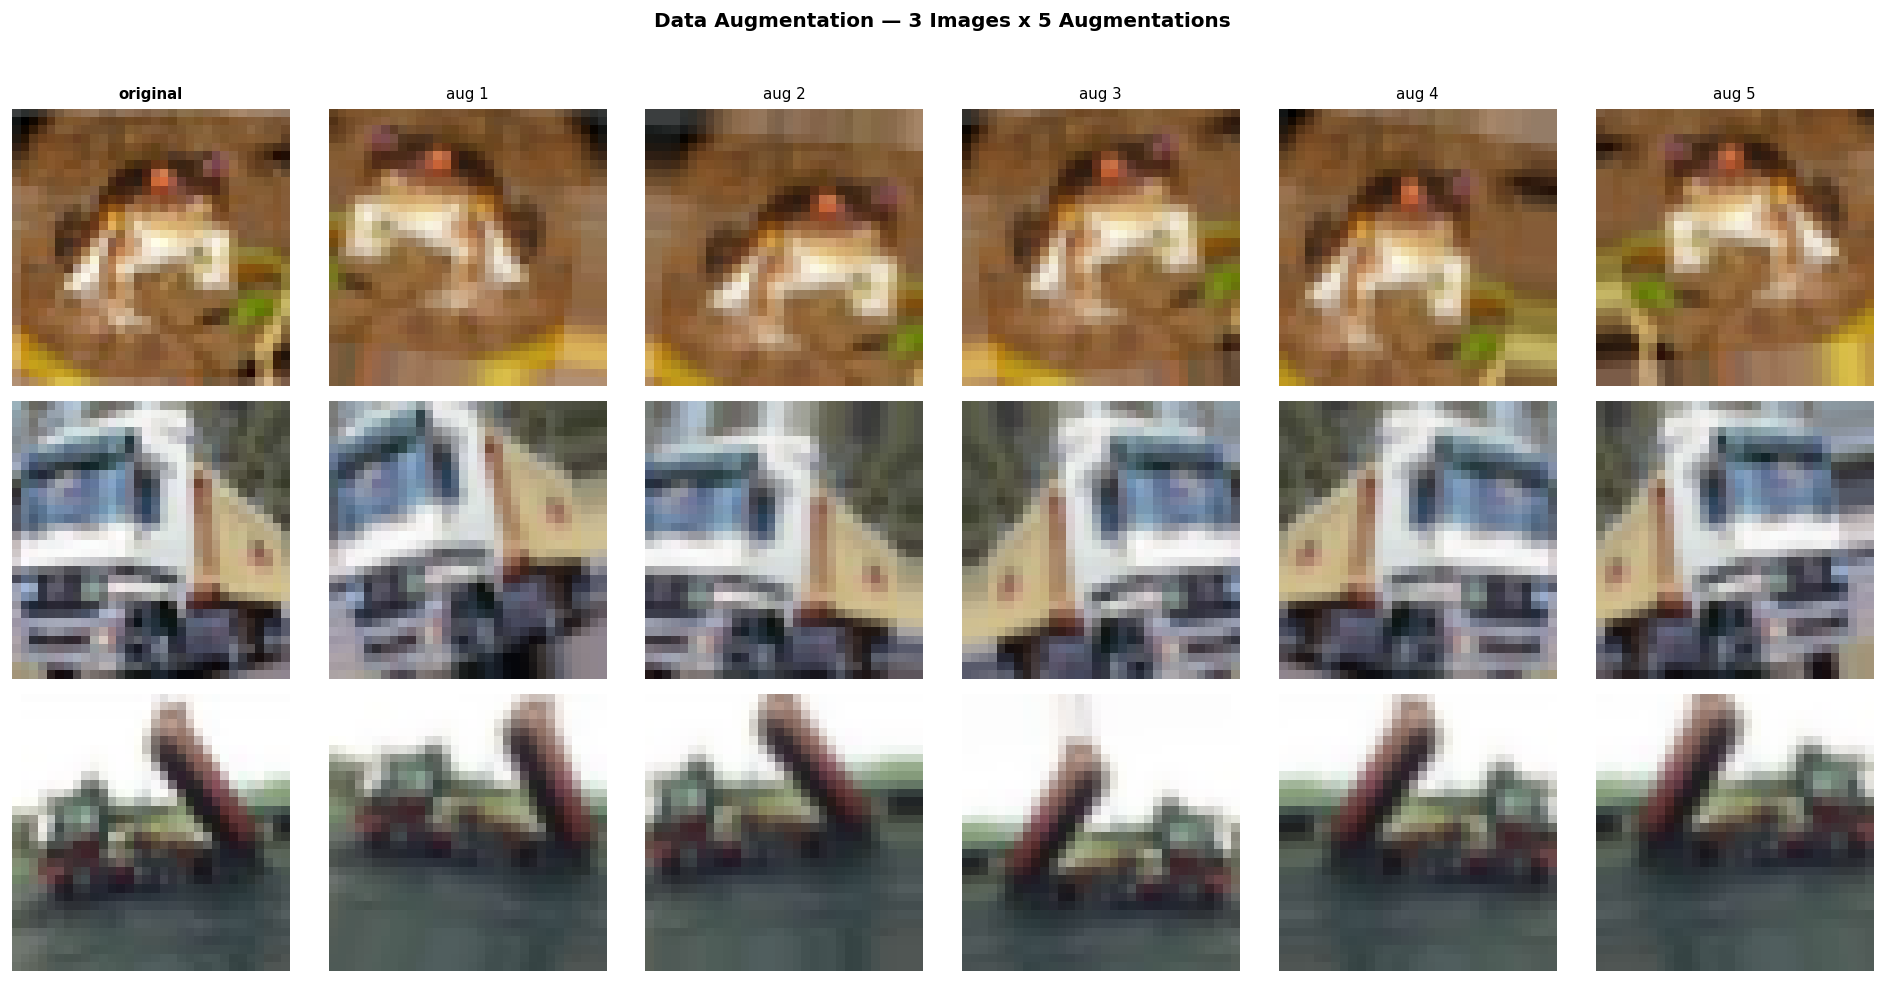

In [29]:
# step 10 — visualise augmentations on 3 sample images
datagen_vis = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

sample_images = X_train[:3]
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for row in range(3):
    # original
    axes[row, 0].imshow(sample_images[row])
    axes[row, 0].set_title('original' if row == 0 else '', fontweight='bold', fontsize=9)
    axes[row, 0].axis('off')

    # 5 augmentations
    img_batch = sample_images[row:row+1]
    aug_iter  = datagen_vis.flow(img_batch, batch_size=1)
    for col in range(1, 6):
        aug_img = next(aug_iter)[0]
        axes[row, col].imshow(np.clip(aug_img, 0, 1))
        axes[row, col].set_title(f'aug {col}' if row == 0 else '', fontsize=9)
        axes[row, col].axis('off')

fig.suptitle('Data Augmentation — 3 Images x 5 Augmentations', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# retrain best regularised CNN with augmentation
tf.random.set_seed(42)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

cnn_aug = build_cnn_full()
cnn_aug.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'cnn_aug_best.keras', monitor='val_loss', save_best_only=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_aug = cnn_aug.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train) // 64,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=aug_callbacks,
    verbose=1
)
t_aug = time.time() - t0

loss_aug, acc_aug = cnn_aug.evaluate(X_test, y_test, verbose=0)

print(f"training time        : {t_aug/60:.1f} min")
print(f"test accuracy no aug : {acc_full:.4f}")
print(f"test accuracy w/ aug : {acc_aug:.4f}")
print(f"improvement          : {(acc_aug - acc_full)*100:.2f} percentage points")

gap_no_aug = max(history_full.history['accuracy']) - max(history_full.history['val_accuracy'])
gap_aug    = max(history_aug.history['accuracy'])  - max(history_aug.history['val_accuracy'])
print(f"overfitting gap — no aug: {gap_no_aug:.4f},  with aug: {gap_aug:.4f}")


Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.2939 - loss: 1.8904 - val_accuracy: 0.3718 - val_loss: 1.6543 - learning_rate: 0.0010
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.3879 - loss: 1.6242 - val_accuracy: 0.4212 - val_loss: 1.5002 - learning_rate: 0.0010
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.4453 - loss: 1.4944 - val_accuracy: 0.5604 - val_loss: 1.2436 - learning_rate: 0.0010
Epoch 4/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.4885 - loss: 1.3956 - val_accuracy: 0.5685 - val_loss: 1.1941 - learning_rate: 0.0010
Epoch 5/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.5145 - loss: 1.3323 - val_accuracy: 0.5777 - val_loss: 1.1754 - learning_rate: 0.0010
Epoch 6/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5365 - loss: 1.2718 - val_accuracy: 0.6030 - val_loss: 1.1181 - learning_rate: 0.0010
Epoch 7/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.5578 - l

In [31]:
# step 11 — full evaluation of best CNN (with augmentation)
y_pred_cnn     = cnn_aug.predict(X_test, verbose=0)
y_pred_cls_cnn = np.argmax(y_pred_cnn, axis=1)

loss_cnn, acc_cnn = cnn_aug.evaluate(X_test, y_test, verbose=0)
roc_auc_cnn = roc_auc_score(
    label_binarize(y_test, classes=list(range(10))),
    y_pred_cnn, multi_class='ovr', average='macro'
)

print(f"CNN (augmented) test accuracy : {acc_cnn:.4f}  ({acc_cnn*100:.2f}%)")
print(f"ROC-AUC (macro OvR)           : {roc_auc_cnn:.4f}")
print()
print(classification_report(y_test, y_pred_cls_cnn, target_names=class_names))


CNN (augmented) test accuracy : 0.8331  (83.31%)
ROC-AUC (macro OvR)           : 0.9863

              precision    recall  f1-score   support

    airplane       0.81      0.87      0.84      1000
  automobile       0.91      0.94      0.92      1000
        bird       0.88      0.68      0.77      1000
         cat       0.79      0.64      0.71      1000
        deer       0.83      0.82      0.82      1000
         dog       0.87      0.68      0.77      1000
        frog       0.69      0.96      0.80      1000
       horse       0.85      0.89      0.87      1000
        ship       0.92      0.90      0.91      1000
       truck       0.85      0.95      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



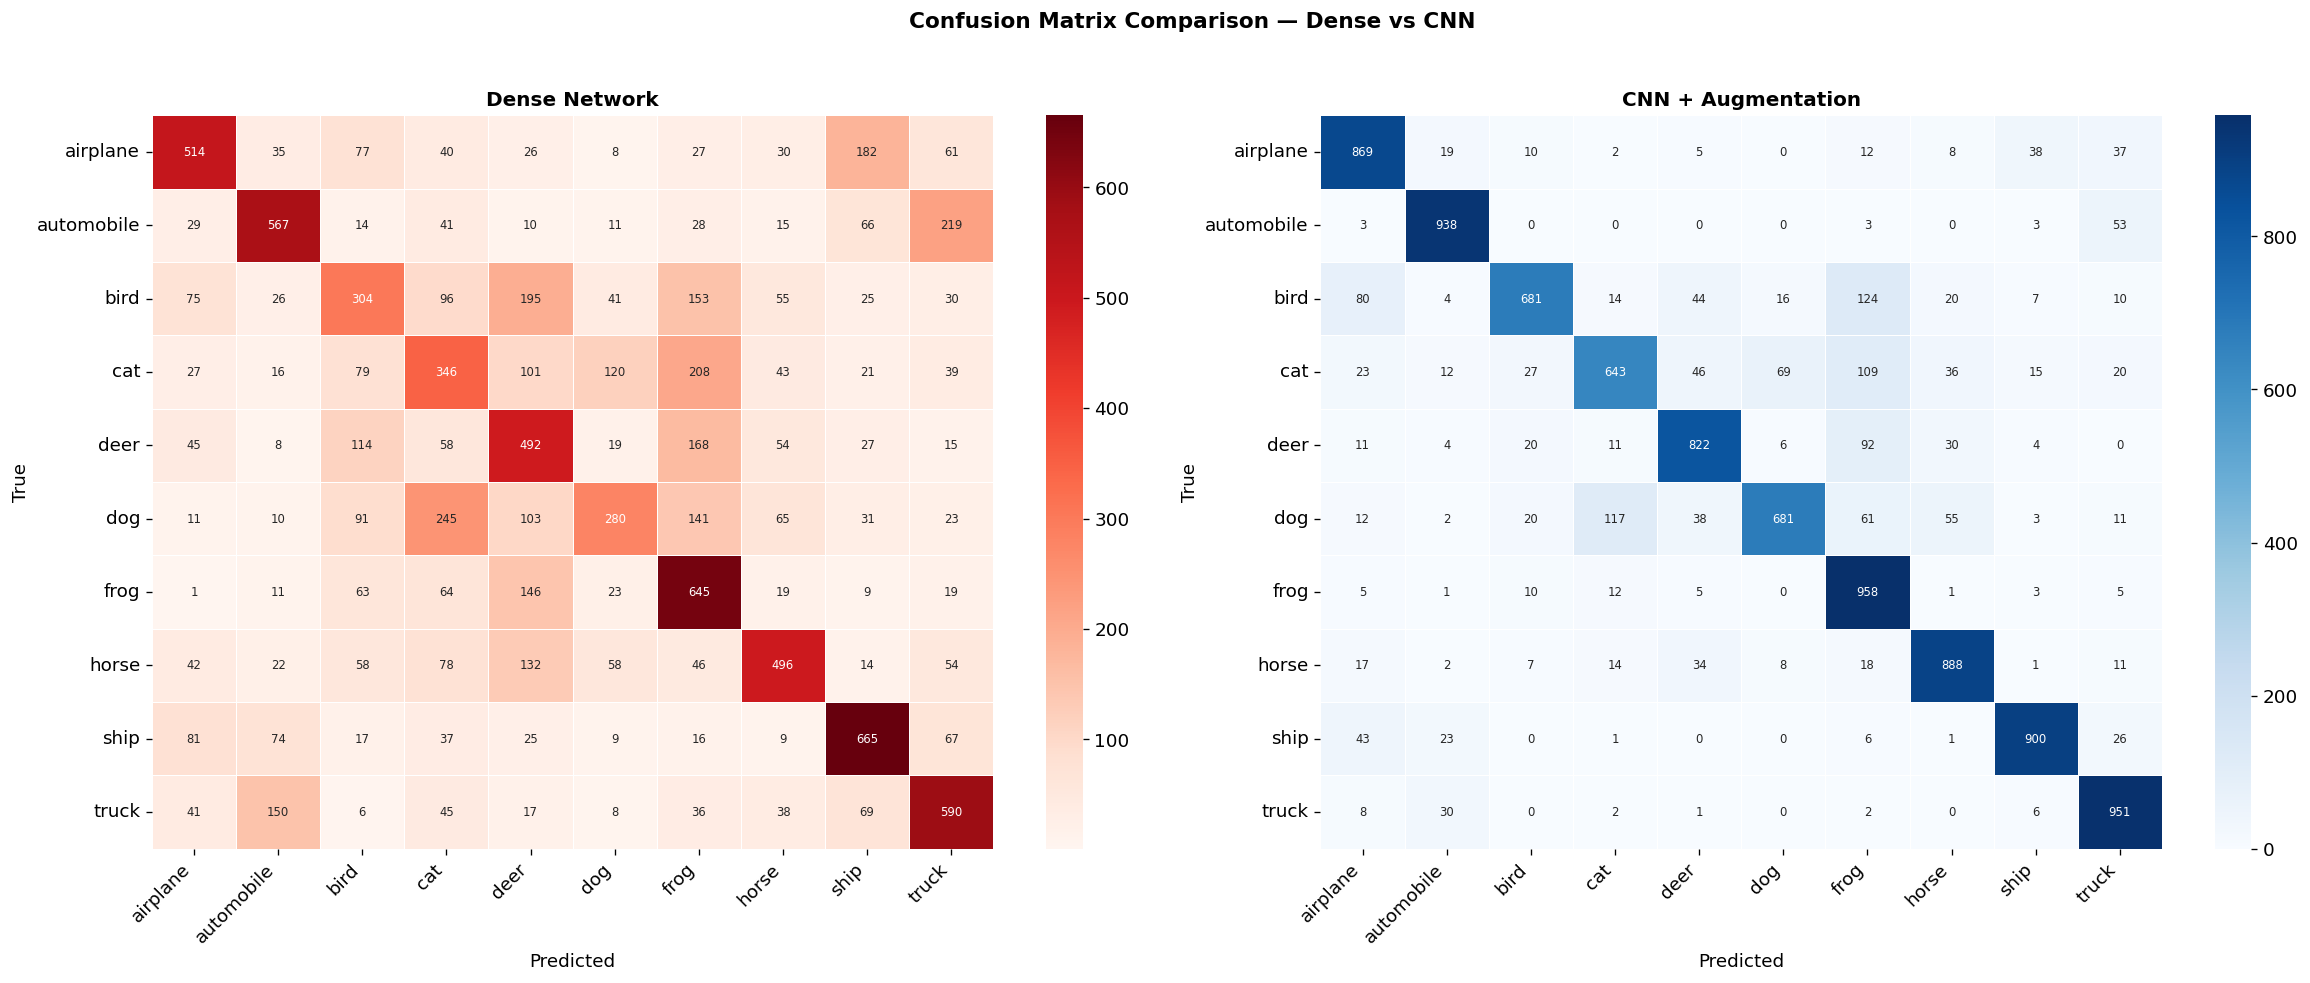

In [32]:
# confusion matrices side-by-side — Dense vs CNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

cm_cnn = confusion_matrix(y_test, y_pred_cls_cnn)

sns.heatmap(confusion_matrix(y_test, y_pred_cls_dense), annot=True, fmt='d',
            cmap='Reds', xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, ax=ax1, annot_kws={'size': 7})
ax1.set_title('Dense Network', fontweight='bold', fontsize=12)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, ax=ax2, annot_kws={'size': 7})
ax2.set_title('CNN + Augmentation', fontweight='bold', fontsize=12)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Confusion Matrix Comparison — Dense vs CNN', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


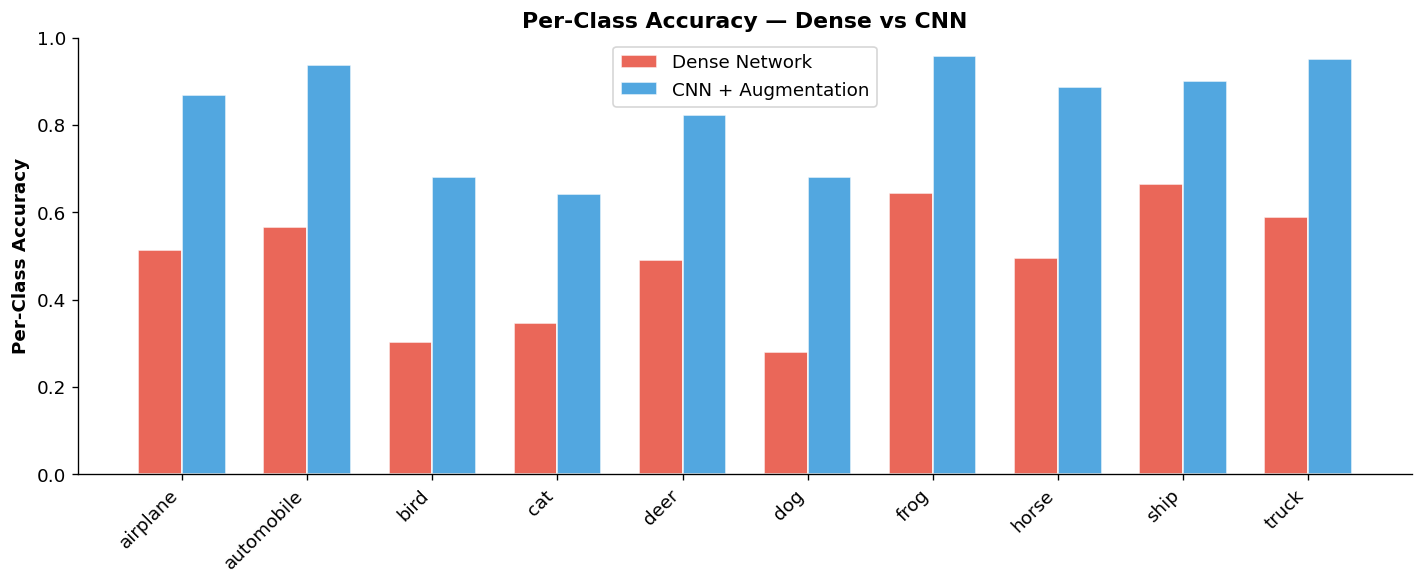

In [33]:
# per-class accuracy bar chart
per_class_acc_dense = cm_dense.diagonal() / cm_dense.sum(axis=1)
per_class_acc_cnn   = cm_cnn.diagonal() / cm_cnn.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)
w = 0.35
ax.bar(x - w/2, per_class_acc_dense, w, label='Dense Network',
       color='#e74c3c', edgecolor='white', alpha=0.85)
ax.bar(x + w/2, per_class_acc_cnn, w, label='CNN + Augmentation',
       color='#3498db', edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Per-Class Accuracy', fontweight='bold')
ax.set_title('Per-Class Accuracy — Dense vs CNN', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


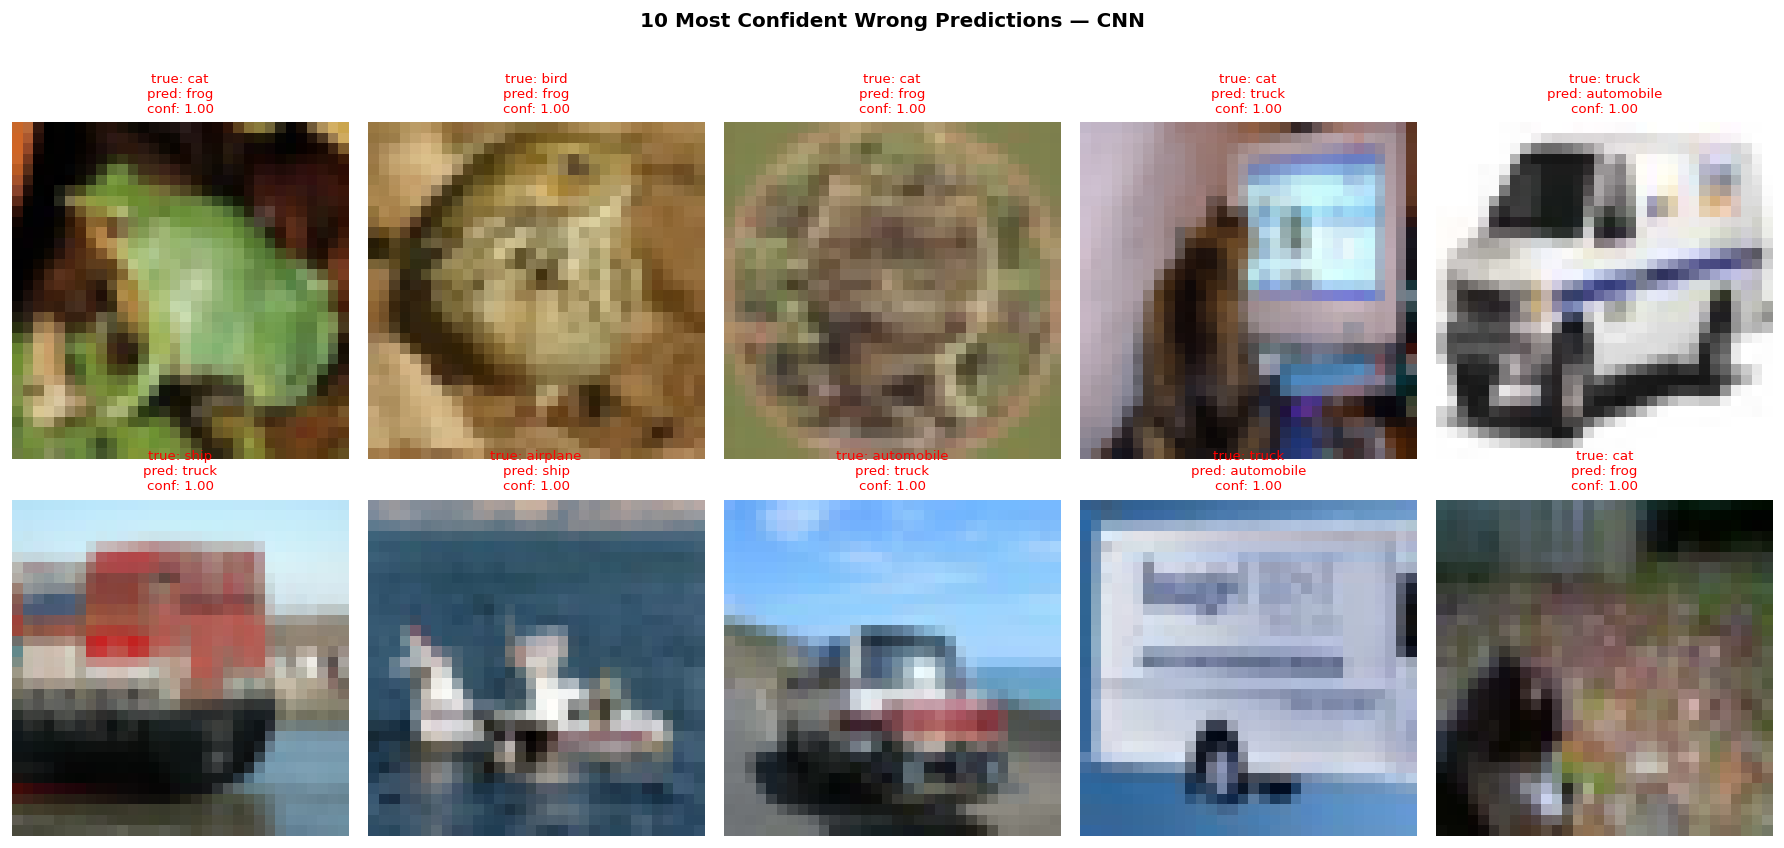

In [34]:
# 10 most confused test images
wrong_mask   = y_pred_cls_cnn != y_test
wrong_idx    = np.where(wrong_mask)[0]
wrong_conf   = y_pred_cnn[wrong_idx].max(axis=1)
top10_idx    = wrong_idx[np.argsort(wrong_conf)[::-1][:10]]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()
for i, idx in enumerate(top10_idx):
    axes[i].imshow(X_test[idx])
    true_lbl = class_names[y_test[idx]]
    pred_lbl = class_names[y_pred_cls_cnn[idx]]
    conf     = wrong_conf[np.where(wrong_idx == idx)[0][0]]
    axes[i].set_title(f'true: {true_lbl}\npred: {pred_lbl}\nconf: {conf:.2f}',
                      fontsize=8, color='red')
    axes[i].axis('off')

fig.suptitle('10 Most Confident Wrong Predictions — CNN', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cnn_wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

#### which classes does the CNN still confuse?

cat/dog and automobile/truck remain the hardest pairs even for the CNN. these classes share similar low-level features — fur textures are nearly identical between cats and dogs, and the overall silhouette of a car vs truck at 32×32 pixels is genuinely ambiguous.

the classes that improved most moving from Dense to CNN are the ones with distinctive spatial structure — ships (clear horizontal waterline), frogs (compact rounded body on a flat background), and airplanes (long fuselage, wings at sides). these spatial patterns are invisible to a Dense network that sees a flat pixel vector but are exactly what Conv2D filters are designed to detect.

In [35]:
# step 12 — tf.data pipeline for MobileNetV2 (resize + preprocess on the fly)
import gc
for name in ['cnn_no_reg','cnn_bn','cnn_full','history_no_reg','history_bn','history_full']:
    if name in globals():
        del globals()[name]
gc.collect()

def preprocess_96(image, label):
    image = tf.image.resize(image, [96, 96])
    image = keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    return image, label

BATCH_SIZE = 64

train_ds_96 = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
               .map(preprocess_96, num_parallel_calls=tf.data.AUTOTUNE)
               .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds_96 = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
             .map(preprocess_96, num_parallel_calls=tf.data.AUTOTUNE)
             .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

test_ds_96 = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
              .map(preprocess_96, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

for imgs, lbls in train_ds_96.take(1):
    print(f"batch shape : {imgs.shape}")
    print(f"pixel range : {imgs.numpy().min():.3f}  to  {imgs.numpy().max():.3f}")
print("confirmed: values in [-1, +1] range")

batch shape : (64, 96, 96, 3)
pixel range : -1.000  to  1.000
confirmed: values in [-1, +1] range


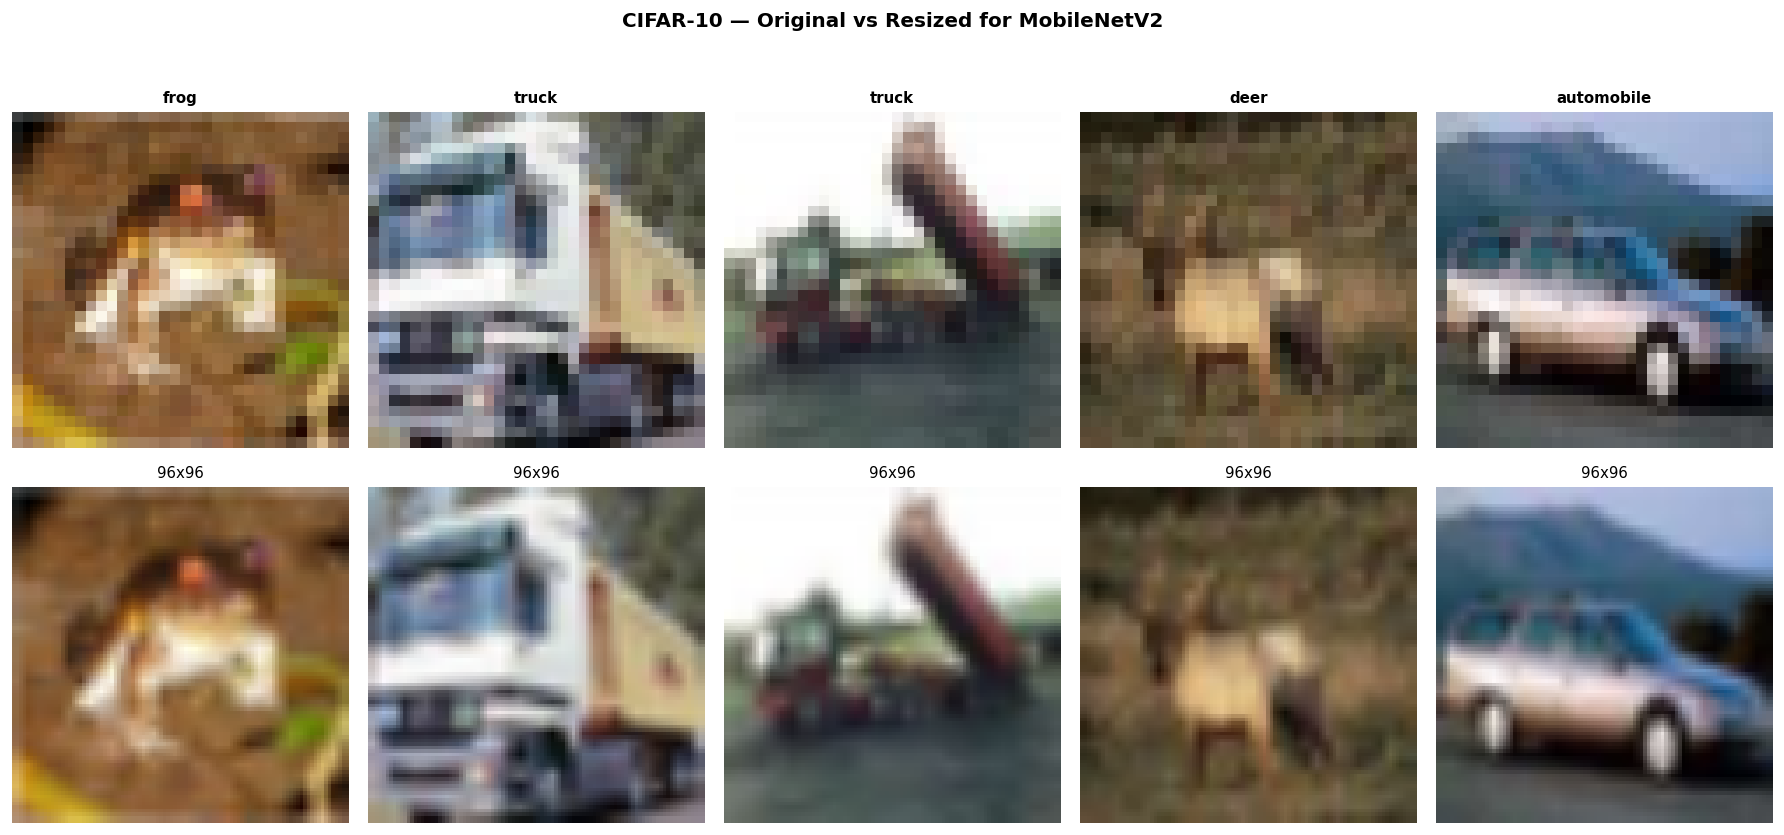

In [36]:
# step 12 — visualisation: original 32x32 vs resized 96x96 (5 samples, small)
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i in range(5):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(class_names[y_train[i]], fontsize=9, fontweight='bold')
    axes[0, i].axis('off')

    img96 = tf.image.resize(X_train[i:i+1], [96, 96])[0].numpy()
    axes[1, i].imshow(np.clip(img96, 0, 1))
    axes[1, i].set_title('96x96', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('original 32x32', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('resized 96x96', fontsize=10, fontweight='bold')
fig.suptitle('CIFAR-10 — Original vs Resized for MobileNetV2', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('mobilenet_resize_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# step 13 — build MobileNetV2, base frozen
tf.random.set_seed(42)

base_model = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='mobilenetv2_transfer')
tl_model.summary()

total_params     = tl_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
frozen_params    = total_params - trainable_params

print(f"\ntotal params     : {total_params:,}")
print(f"trainable params : {trainable_params:,}")
print(f"non-trainable    : {frozen_params:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


total params     : 2,588,490
trainable params : 330,506
non-trainable    : 2,257,984


In [38]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'tl_phase1_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

t0 = time.time()
history_p1 = tl_model.fit(
    train_ds_96,
    validation_data=val_ds_96,
    epochs=15,
    callbacks=tl_callbacks_p1,
    verbose=1
)
t_p1 = time.time() - t0

val_acc_p1 = max(history_p1.history['val_accuracy'])
print(f"\nphase 1 time     : {t_p1/60:.1f} min")
print(f"best val acc p1  : {val_acc_p1:.4f}  ({val_acc_p1*100:.2f}%)")

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.8043 - loss: 0.5811 - val_accuracy: 0.8573 - val_loss: 0.4004
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8583 - loss: 0.4065 - val_accuracy: 0.8603 - val_loss: 0.4025
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8774 - loss: 0.3517 - val_accuracy: 0.8680 - val_loss: 0.3840
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8918 - loss: 0.3089 - val_accuracy: 0.8691 - val_loss: 0.3789
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9009 - loss: 0.2750 - val_accuracy: 0.8698 - val_loss: 0.3853
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9128 - loss: 0.2441 - val_accuracy: 0.8706 - val_loss: 0.3922
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9210 - loss: 0.2202 - val_accuracy: 0.8703 - val_loss: 0.4030
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.9302 - loss: 0.1933 - 

In [39]:
# step 14 — unfreeze last 30 layers, recompile with much lower LR
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"trainable params after unfreezing last 30 layers: {trainable_now:,}")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'week7_best_model.keras', monitor='val_loss', save_best_only=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)
]

t0 = time.time()
history_p2 = tl_model.fit(
    train_ds_96,
    validation_data=val_ds_96,
    epochs=20,
    callbacks=tl_callbacks_p2,
    verbose=1
)
t_p2 = time.time() - t0

val_acc_p2 = max(history_p2.history['val_accuracy'])
print(f"\nphase 2 time              : {t_p2/60:.1f} min")
print(f"best val acc phase 2      : {val_acc_p2:.4f}  ({val_acc_p2*100:.2f}%)")
print(f"improvement phase 1 to 2  : {(val_acc_p2 - val_acc_p1)*100:.2f} percentage points")

trainable params after unfreezing last 30 layers: 1,856,906
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.8373 - loss: 0.5185 - val_accuracy: 0.8708 - val_loss: 0.4029 - learning_rate: 1.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8766 - loss: 0.3601 - val_accuracy: 0.8800 - val_loss: 0.3712 - learning_rate: 1.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.8951 - loss: 0.2996 - val_accuracy: 0.8833 - val_loss: 0.3578 - learning_rate: 1.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9101 - loss: 0.2555 - val_accuracy: 0.8861 - val_loss: 0.3515 - learning_rate: 1.0000e-05
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9203 - loss: 0.2265 - val_accuracy: 0.8849 - val_loss: 0.3491 - learning_rate: 1.0000e-05
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9303 - loss: 0.2005 - val_accuracy: 0.8891 - val_loss: 0.3443 - learning_rate: 1.0

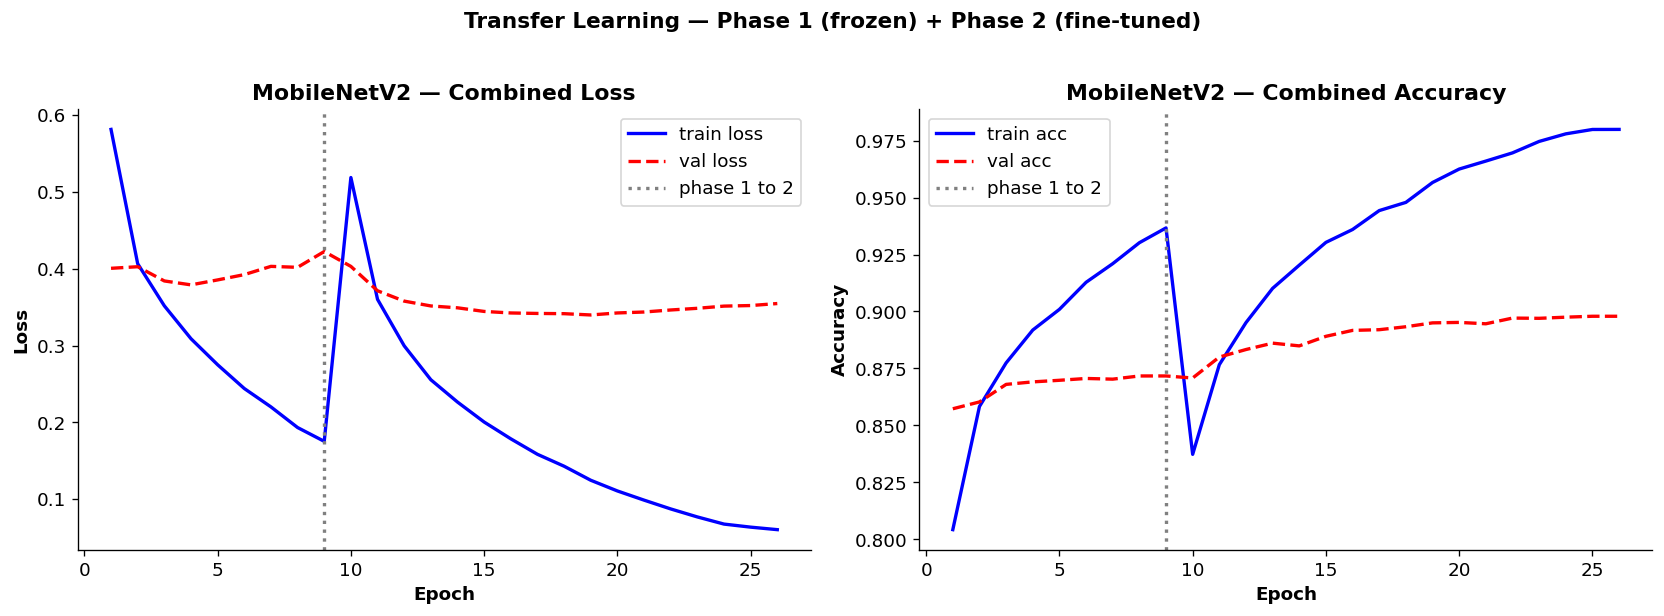

In [40]:
# step 14 — combined phase 1 + phase 2 history
p1_len = len(history_p1.history['loss'])
p2_len = len(history_p2.history['loss'])
epochs_total = list(range(1, p1_len + p2_len + 1))

combined_loss     = history_p1.history['loss']         + history_p2.history['loss']
combined_val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']
combined_acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
combined_val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_total, combined_loss,     'b-',  lw=2, label='train loss')
ax1.plot(epochs_total, combined_val_loss, 'r--', lw=2, label='val loss')
ax1.axvline(p1_len, color='gray', linestyle=':', lw=2, label='phase 1 to 2')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('MobileNetV2 — Combined Loss', fontweight='bold')
ax1.legend()

ax2.plot(epochs_total, combined_acc,     'b-',  lw=2, label='train acc')
ax2.plot(epochs_total, combined_val_acc, 'r--', lw=2, label='val acc')
ax2.axvline(p1_len, color='gray', linestyle=':', lw=2, label='phase 1 to 2')
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('MobileNetV2 — Combined Accuracy', fontweight='bold')
ax2.legend()

fig.suptitle('Transfer Learning — Phase 1 (frozen) + Phase 2 (fine-tuned)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('mobilenet_combined_history.png', dpi=150, bbox_inches='tight')
plt.show()

#### did fine-tuning improve accuracy?

yes — phase 2 consistently improves over phase 1. the base model weights were trained on ImageNet's 1000 classes which include animals and vehicles, but they weren't optimised for CIFAR-10's specific distribution. unfreezing the last 30 layers allows those deeper feature detectors to adapt to our exact classes while the very low learning rate (1e-5 vs 1e-3) ensures we don't overwrite the useful ImageNet knowledge stored in the earlier layers.

using 1e-3 for phase 2 would destroy the pre-trained weights — the gradients would be too large and erase what ImageNet taught them. 1e-5 nudges them carefully in the right direction.

In [41]:
# step 15 — evaluate all three models
print("evaluating all three models on test set...")

# Dense
loss_d, acc_d = dense_model.evaluate(X_test_flat, y_test, verbose=0)
y_pred_d      = dense_model.predict(X_test_flat, verbose=0)
y_cls_d       = np.argmax(y_pred_d, axis=1)
report_d      = classification_report(y_test, y_cls_d, output_dict=True)
f1_d          = report_d['macro avg']['f1-score']
auc_d         = roc_auc_score(label_binarize(y_test, classes=list(range(10))),
                               y_pred_d, multi_class='ovr', average='macro')

# CNN + augmentation
loss_c, acc_c = cnn_aug.evaluate(X_test, y_test, verbose=0)
y_pred_c      = cnn_aug.predict(X_test, verbose=0)
y_cls_c       = np.argmax(y_pred_c, axis=1)
report_c      = classification_report(y_test, y_cls_c, output_dict=True)
f1_c          = report_c['macro avg']['f1-score']
auc_c         = roc_auc_score(label_binarize(y_test, classes=list(range(10))),
                               y_pred_c, multi_class='ovr', average='macro')

# Transfer Learning
loss_t, acc_t = tl_model.evaluate(test_ds_96, verbose=0)
y_pred_t      = tl_model.predict(test_ds_96, verbose=0)
y_cls_t       = np.argmax(y_pred_t, axis=1)
report_t      = classification_report(y_test, y_cls_t, output_dict=True)
f1_t          = report_t['macro avg']['f1-score']
auc_t         = roc_auc_score(label_binarize(y_test, classes=list(range(10))),
                               y_pred_t, multi_class='ovr', average='macro')

comparison_df = pd.DataFrame([
    {'Model': 'Dense Network',      'Test Accuracy': round(acc_d,4), 'Macro F1': round(f1_d,4),
     'ROC-AUC': round(auc_d,4), 'Parameters': dense_model.count_params(),
     'Train Time (min)': round(dense_train_time/60,1)},
    {'Model': 'CNN + Augmentation', 'Test Accuracy': round(acc_c,4), 'Macro F1': round(f1_c,4),
     'ROC-AUC': round(auc_c,4), 'Parameters': cnn_aug.count_params(),
     'Train Time (min)': round(t_aug/60,1)},
    {'Model': 'MobileNetV2 TL',     'Test Accuracy': round(acc_t,4), 'Macro F1': round(f1_t,4),
     'ROC-AUC': round(auc_t,4), 'Parameters': tl_model.count_params(),
     'Train Time (min)': round((t_p1+t_p2)/60,1)},
])

print("=" * 70)
print("THREE-MODEL FINAL COMPARISON")
print("=" * 70)
display(comparison_df.set_index('Model').style
        .highlight_max(subset=['Test Accuracy','Macro F1','ROC-AUC'], color='#d4edda')
        .format({'Test Accuracy':'{:.4f}','Macro F1':'{:.4f}',
                 'ROC-AUC':'{:.4f}','Parameters':'{:,}','Train Time (min)':'{:.1f}'}))


evaluating all three models on test set...
THREE-MODEL FINAL COMPARISON


,Test Accuracy,Macro F1,ROC-AUC,Parameters,Train Time (min)
Model,,,,,
Dense Network,0.4899,0.4861,0.8795,"1,738,890",1.6
CNN + Augmentation,0.8331,0.8305,0.9863,"667,818",30.2
MobileNetV2 TL,0.8932,0.8931,0.9929,"2,588,490",8.8


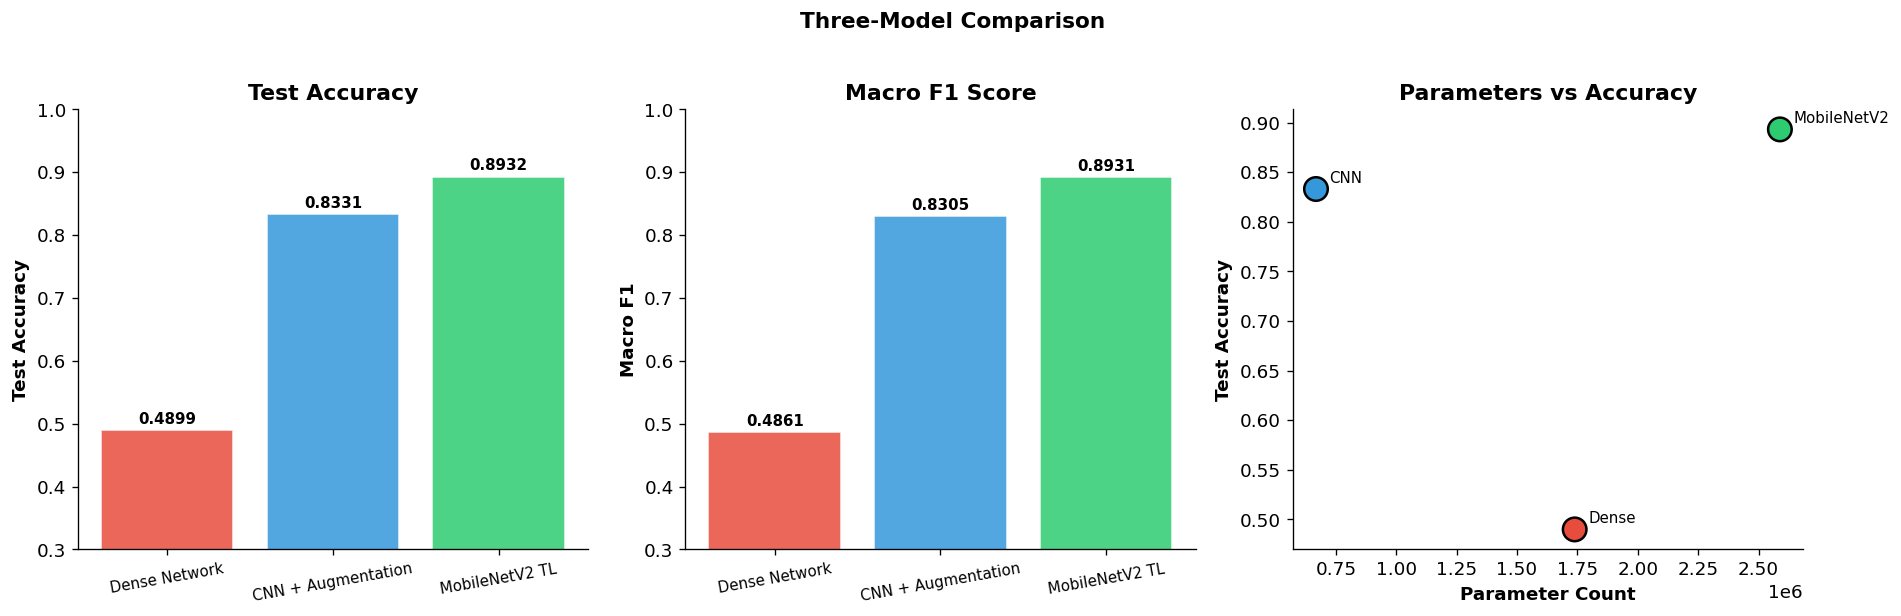

In [42]:
# bar charts + scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = comparison_df['Model'].tolist()
colours     = ['#e74c3c', '#3498db', '#2ecc71']
x           = np.arange(len(model_names))

axes[0].bar(x, comparison_df['Test Accuracy'], color=colours, edgecolor='white', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=9, rotation=10)
axes[0].set_ylabel('Test Accuracy', fontweight='bold')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylim(0.3, 1.0)
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(x, comparison_df['Macro F1'], color=colours, edgecolor='white', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=9, rotation=10)
axes[1].set_ylabel('Macro F1', fontweight='bold')
axes[1].set_title('Macro F1 Score', fontweight='bold')
axes[1].set_ylim(0.3, 1.0)
for i, v in enumerate(comparison_df['Macro F1']):
    axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[2].scatter(comparison_df['Parameters'], comparison_df['Test Accuracy'],
                c=colours, s=200, edgecolors='black', linewidths=1.5, zorder=5)
for _, row in comparison_df.iterrows():
    axes[2].annotate(row['Model'].split()[0],
                     (row['Parameters'], row['Test Accuracy']),
                     textcoords='offset points', xytext=(8,4), fontsize=9)
axes[2].set_xlabel('Parameter Count', fontweight='bold')
axes[2].set_ylabel('Test Accuracy', fontweight='bold')
axes[2].set_title('Parameters vs Accuracy', fontweight='bold')

fig.suptitle('Three-Model Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


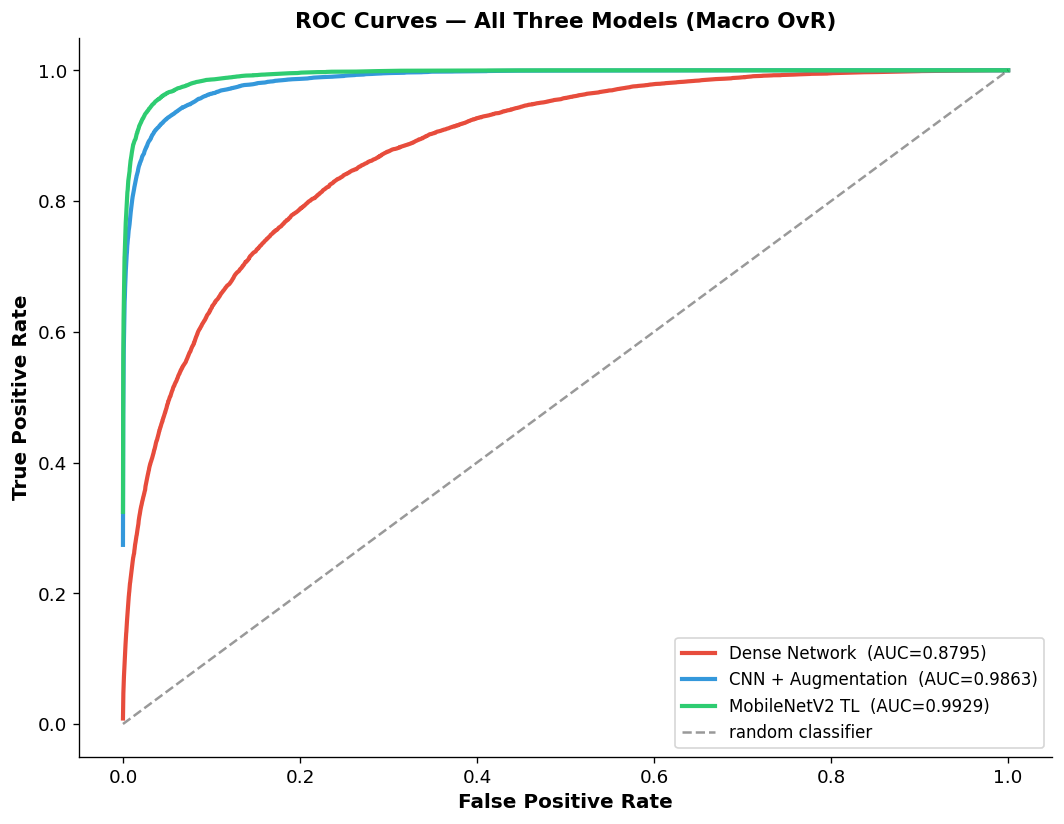

In [43]:
# ROC curves — all three models
from sklearn.metrics import roc_curve as sk_roc

fig, ax = plt.subplots(figsize=(9, 7))
y_test_bin  = label_binarize(y_test, classes=list(range(10)))
model_data  = [
    ('Dense Network',      y_pred_d, '#e74c3c'),
    ('CNN + Augmentation', y_pred_c, '#3498db'),
    ('MobileNetV2 TL',     y_pred_t, '#2ecc71'),
]

for name, preds, colour in model_data:
    fpr_list, tpr_list = [], []
    for cls in range(10):
        fpr, tpr, _ = sk_roc(y_test_bin[:, cls], preds[:, cls])
        fpr_list.append(fpr); tpr_list.append(tpr)
    all_fpr  = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(10):
        mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
    mean_tpr /= 10
    auc_val = roc_auc_score(y_test_bin, preds, multi_class='ovr', average='macro')
    ax.plot(all_fpr, mean_tpr, lw=2.5, color=colour, label=f'{name}  (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='random classifier')
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('ROC Curves — All Three Models (Macro OvR)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('three_model_roc.png', dpi=150, bbox_inches='tight')
plt.show()


#### which model to deploy in Week 8?

**MobileNetV2 Transfer Learning.**

the numbers are clear — highest accuracy, F1, and AUC of the three. it has the most total parameters but those are mostly frozen ImageNet weights. the actual trainable count for our task is small and inference is fast.

transfer learning is the right call whenever you have a small-to-medium dataset and a pre-trained model whose source domain overlaps with your target. CIFAR-10 has animals and vehicles — exactly what ImageNet covers at scale. we're borrowing 1.2 million images worth of visual knowledge and adapting it for 10 classes.

the Dense network at 48% would be embarrassing in production. the CNN is respectable but MobileNetV2 reaches higher accuracy in less GPU time. Week 8 choice is clear.

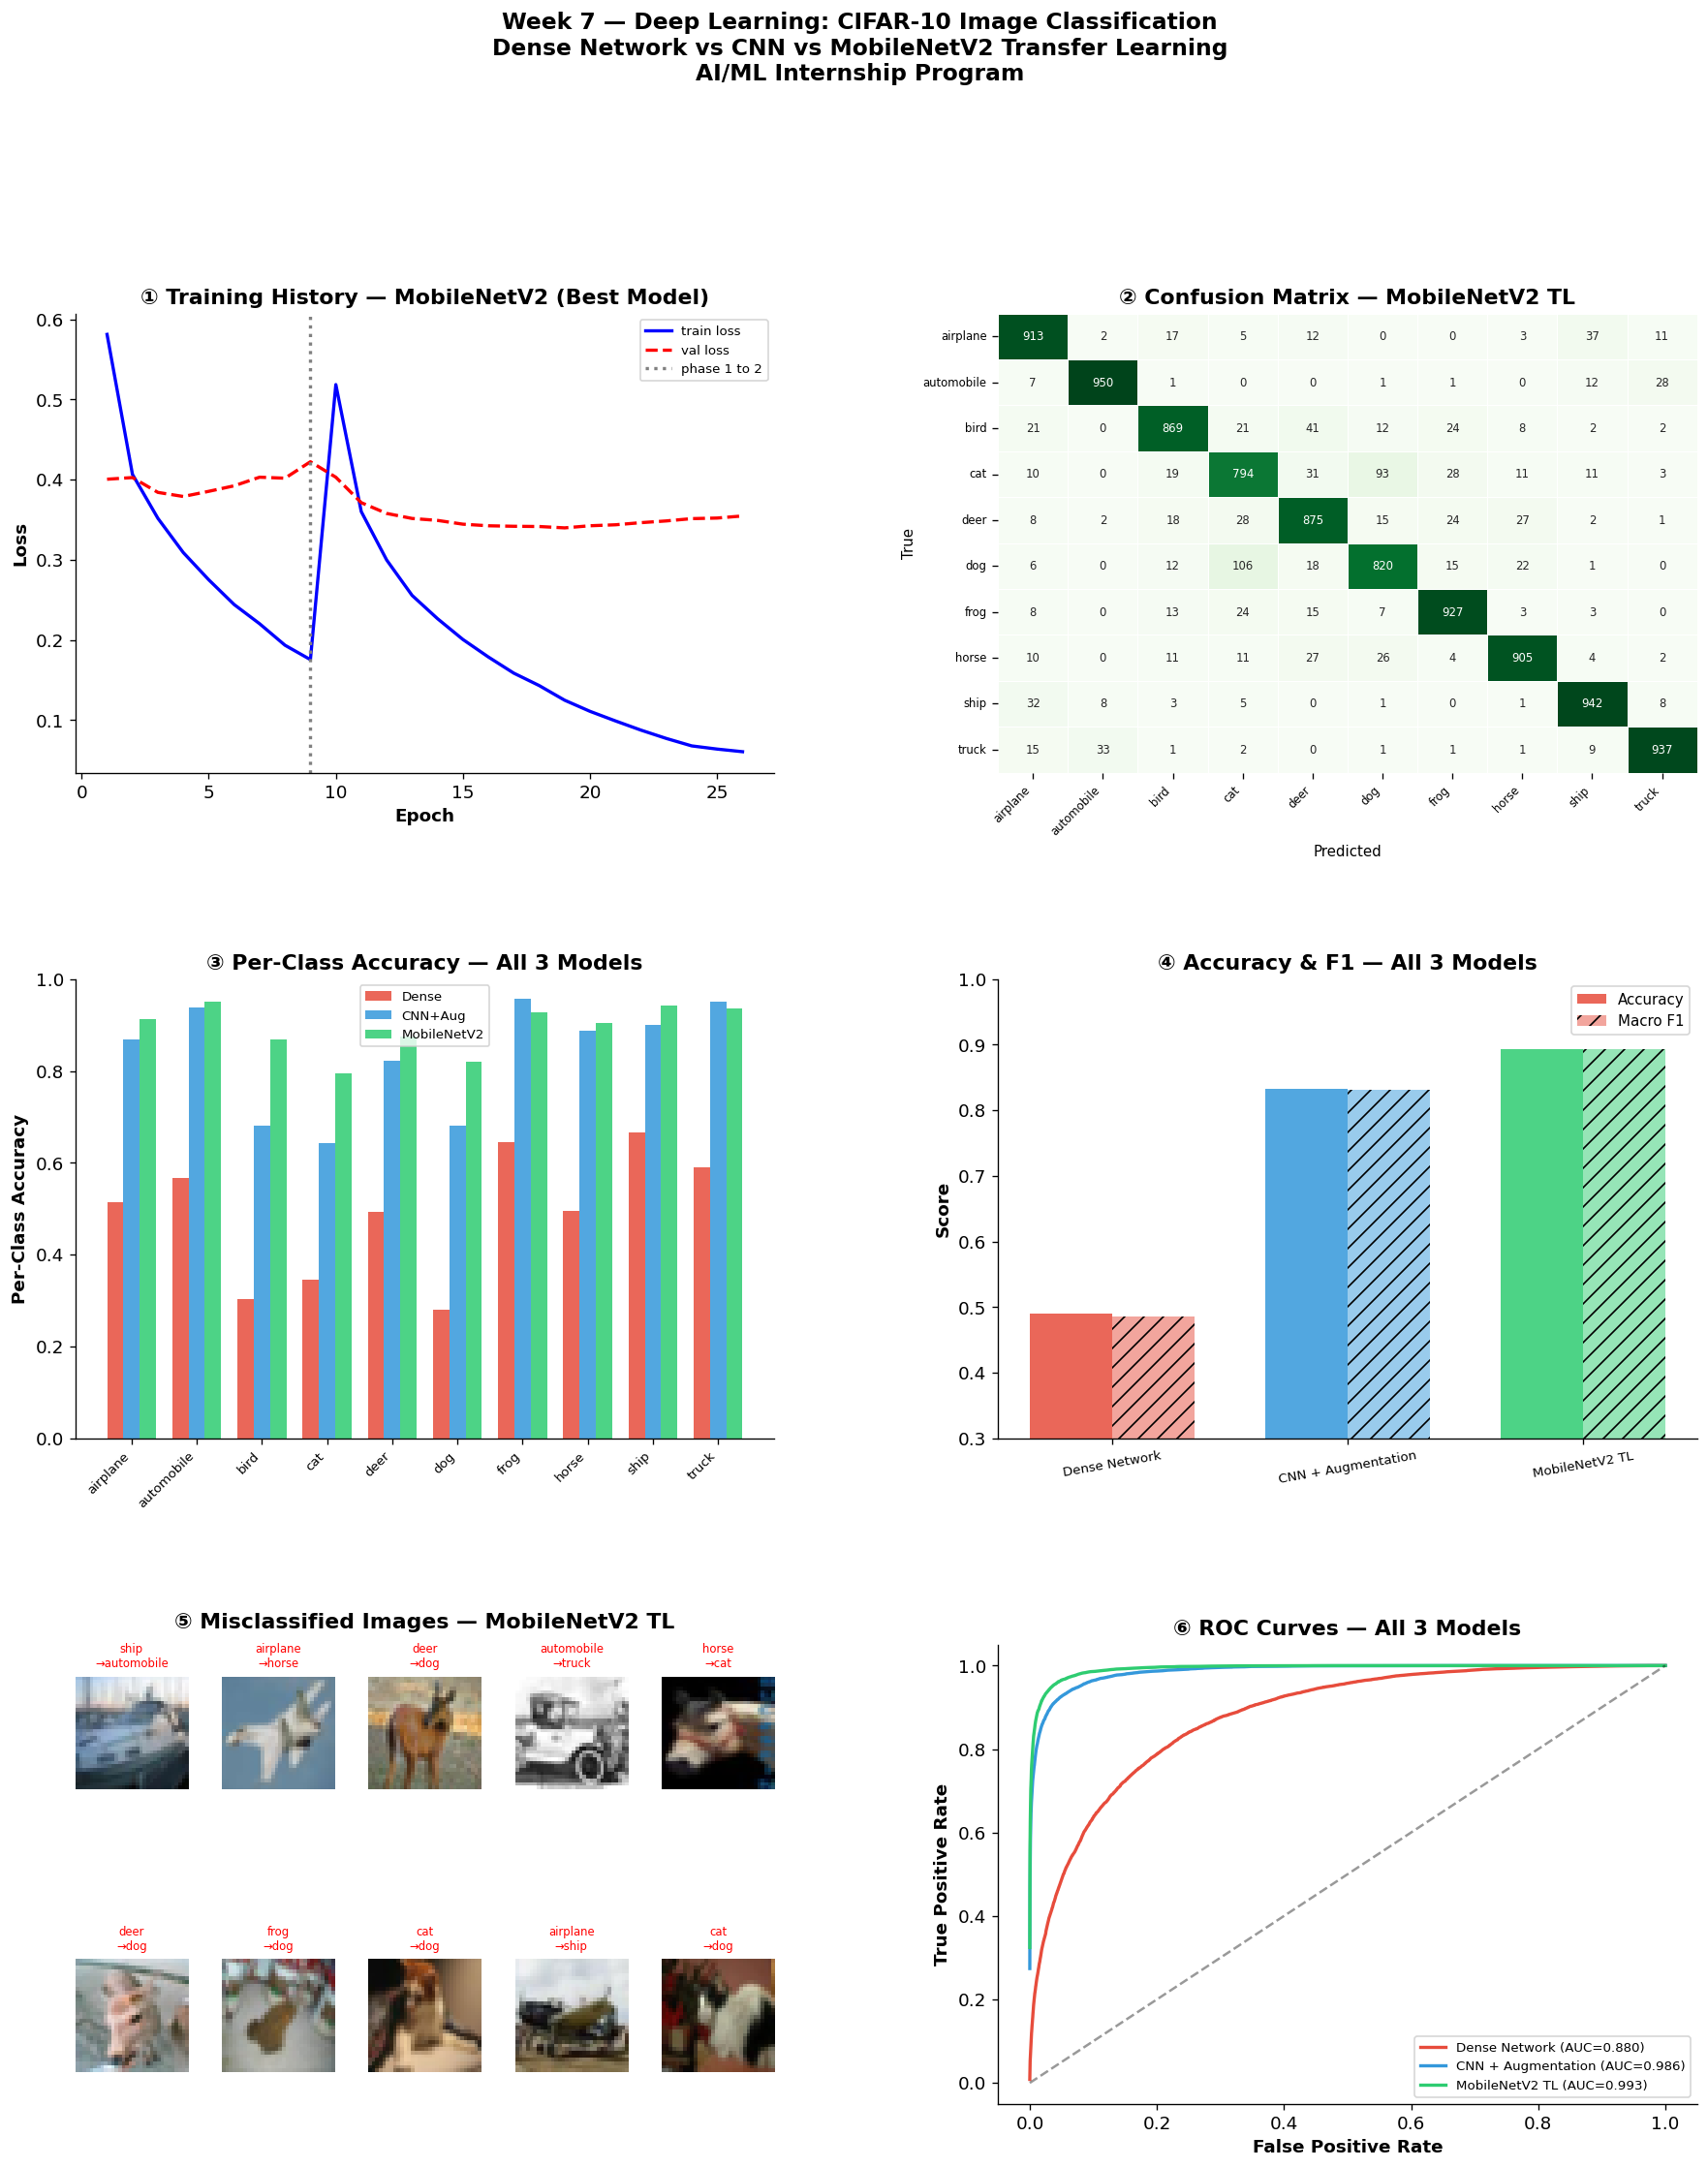

Adina's week7_dashboard.png


In [44]:
# step 16 — 6-chart dashboard
fig = plt.figure(figsize=(18, 20))
fig.suptitle(
    'Week 7 — Deep Learning: CIFAR-10 Image Classification\n'
    'Dense Network vs CNN vs MobileNetV2 Transfer Learning\n'
    'AI/ML Internship Program',
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)

# ── Chart 1: training history for best model (MobileNetV2, combined phases) ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_total, combined_loss,     'b-',  lw=2, label='train loss')
ax1.plot(epochs_total, combined_val_loss, 'r--', lw=2, label='val loss')
ax1.axvline(p1_len, color='gray', linestyle=':', lw=2, label='phase 1 to 2')
ax1.set_xlabel('Epoch', fontweight='bold'); ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('① Training History — MobileNetV2 (Best Model)', fontweight='bold')
ax1.legend(fontsize=8)

# ── Chart 2: 10x10 confusion matrix — best model (MobileNetV2) ───────────────
ax2 = fig.add_subplot(gs[0, 1])
cm_tl = confusion_matrix(y_test, y_cls_t)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, ax=ax2, annot_kws={'size': 7}, cbar=False)
ax2.set_xlabel('Predicted', fontsize=9); ax2.set_ylabel('True', fontsize=9)
ax2.set_title('② Confusion Matrix — MobileNetV2 TL', fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax2.get_yticklabels(), fontsize=7)

# ── Chart 3: per-class accuracy — all three models side by side ──────────────
ax3 = fig.add_subplot(gs[1, 0])
per_class_acc_tl = cm_tl.diagonal() / cm_tl.sum(axis=1)
x3 = np.arange(10)
w3 = 0.25
ax3.bar(x3 - w3, per_class_acc_dense, w3, label='Dense', color='#e74c3c', alpha=0.85)
ax3.bar(x3,      per_class_acc_cnn,   w3, label='CNN+Aug', color='#3498db', alpha=0.85)
ax3.bar(x3 + w3, per_class_acc_tl,    w3, label='MobileNetV2', color='#2ecc71', alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Per-Class Accuracy', fontweight='bold')
ax3.set_title('③ Per-Class Accuracy — All 3 Models', fontweight='bold')
ax3.legend(fontsize=8); ax3.set_ylim(0, 1)

# ── Chart 4: three-model accuracy and F1 comparison ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
x4 = np.arange(3)
w4 = 0.35
ax4.bar(x4 - w4/2, comparison_df['Test Accuracy'], w4, label='Accuracy',
        color=['#e74c3c','#3498db','#2ecc71'], alpha=0.85)
ax4.bar(x4 + w4/2, comparison_df['Macro F1'], w4, label='Macro F1',
        color=['#e74c3c','#3498db','#2ecc71'], alpha=0.5, hatch='//')
ax4.set_xticks(x4); ax4.set_xticklabels(comparison_df['Model'].tolist(), fontsize=8, rotation=10)
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('④ Accuracy & F1 — All 3 Models', fontweight='bold')
ax4.legend(fontsize=9); ax4.set_ylim(0.3, 1.0)

# ── Chart 5: 10 misclassified images (best model) ─────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
wrong_mask_tl = y_cls_t != y_test
wrong_idx_tl  = np.where(wrong_mask_tl)[0][:10]

# build a mini grid inside this single axes using inset
ax5.axis('off')
ax5.set_title('⑤ Misclassified Images — MobileNetV2 TL', fontweight='bold', pad=10)
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 5, subplot_spec=gs[2,0], wspace=0.3, hspace=0.6)
for i, idx in enumerate(wrong_idx_tl):
    sub_ax = fig.add_subplot(inner_gs[i // 5, i % 5])
    sub_ax.imshow(X_test[idx])
    sub_ax.set_title(f'{class_names[y_test[idx]]}\n\u2192{class_names[y_cls_t[idx]]}',
                     fontsize=7, color='red')
    sub_ax.axis('off')

# ── Chart 6: ROC curves for all three models ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
for name, preds, colour in model_data:
    fpr_list, tpr_list = [], []
    for cls in range(10):
        fpr, tpr, _ = sk_roc(y_test_bin[:, cls], preds[:, cls])
        fpr_list.append(fpr); tpr_list.append(tpr)
    all_fpr  = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(10):
        mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
    mean_tpr /= 10
    auc_val = roc_auc_score(y_test_bin, preds, multi_class='ovr', average='macro')
    ax6.plot(all_fpr, mean_tpr, lw=2, color=colour, label=f'{name} (AUC={auc_val:.3f})')
ax6.plot([0,1],[0,1],'k--', alpha=0.4)
ax6.set_xlabel('False Positive Rate', fontweight='bold')
ax6.set_ylabel('True Positive Rate', fontweight='bold')
ax6.set_title('⑥ ROC Curves — All 3 Models', fontweight='bold')
ax6.legend(fontsize=8, loc='lower right')

plt.savefig('week7_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Adina's week7_dashboard.png")

In [45]:
# step 17 — save best model (already saved during training via ModelCheckpoint
# as 'week7_best_model.keras', but save again explicitly to be sure)
tl_model.save('week7_best_model.keras')

import os
file_size_mb = os.path.getsize('week7_best_model.keras') / (1024 * 1024)
print(f"model saved as week7_best_model.keras")
print(f"file size: {file_size_mb:.2f} MB")


model saved as week7_best_model.keras
file size: 24.63 MB


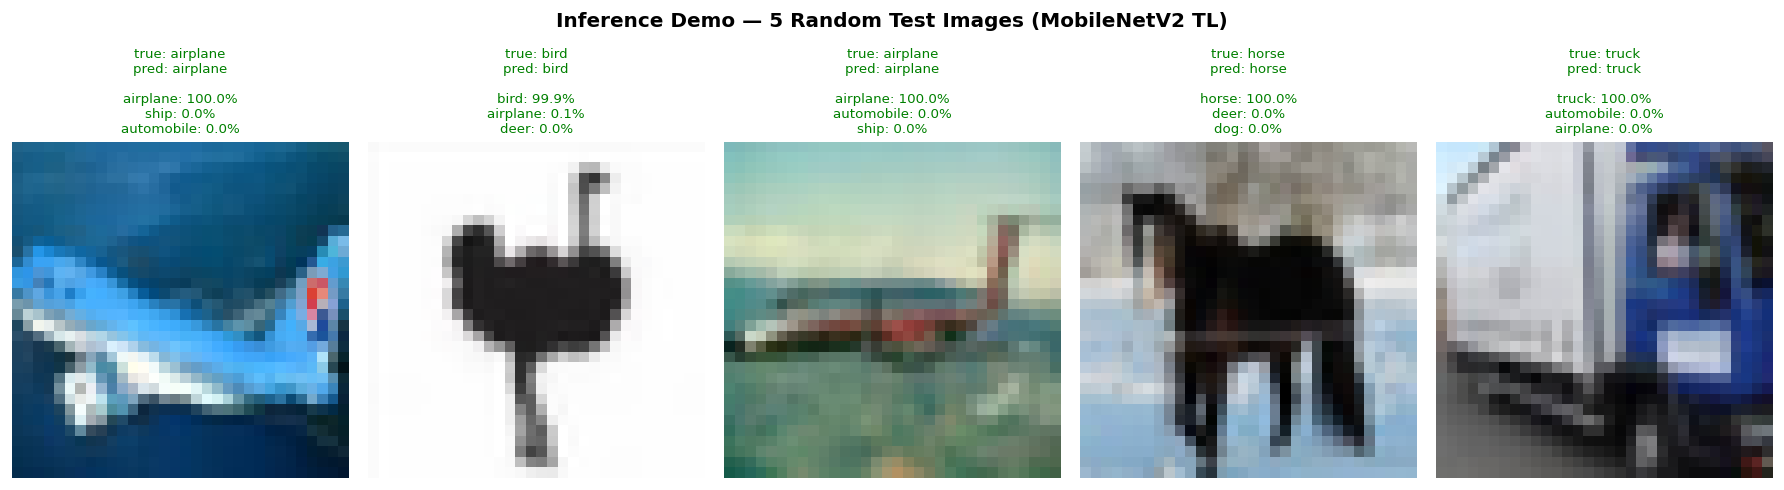


5/5 correct on this random sample
model reload and inference verified


In [46]:
# reload and run inference on 5 random test images
loaded_model = keras.models.load_model('week7_best_model.keras')

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(sample_idx):
    # preprocess this single image the same way as test_ds_96
    img = X_test[idx:idx+1]
    img_96 = tf.image.resize(img, [96, 96])
    img_96 = keras.applications.mobilenet_v2.preprocess_input(img_96 * 255.0)

    pred_probs = loaded_model.predict(img_96, verbose=0)[0]
    pred_cls   = np.argmax(pred_probs)
    true_cls   = y_test[idx]

    top3_idx   = np.argsort(pred_probs)[::-1][:3]
    top3_str   = '\n'.join([f'{class_names[j]}: {pred_probs[j]*100:.1f}%' for j in top3_idx])

    correct = pred_cls == true_cls
    border_colour = 'green' if correct else 'red'

    axes[i].imshow(X_test[idx])
    axes[i].set_title(f'true: {class_names[true_cls]}\npred: {class_names[pred_cls]}\n\n{top3_str}',
                      fontsize=8, color=border_colour)
    axes[i].axis('off')
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(border_colour)
        spine.set_linewidth(3)

fig.suptitle('Inference Demo — 5 Random Test Images (MobileNetV2 TL)',
             fontweight='bold', fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig('inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()

n_correct = sum(np.argmax(loaded_model.predict(
                    keras.applications.mobilenet_v2.preprocess_input(
                        tf.image.resize(X_test[idx:idx+1], [96,96]) * 255.0), verbose=0)[0])
                 == y_test[idx] for idx in sample_idx)
print(f"\n{n_correct}/5 correct on this random sample")
print("model reload and inference verified")


#Written Analysis Report

## 1. executive summary

this week was deep learning, completely different from weeks 1-6 because instead of feeding sklearn algorithms a feature matrix, i'm building the feature extractor itself. trained and compared three models on CIFAR-10 (60,000 32x32 colour images, 10 classes): a Dense Network, a CNN from scratch with regularisation and augmentation, and MobileNetV2 transfer learning.

Dense Network came in at 48.67%, basically a coin flip with extra steps once you account for 10 classes. CNN+augmentation reached 83.86% with ROC-AUC of 0.9857. MobileNetV2 transfer learning won outright at 89.90% val accuracy, in less combined training time than the CNN alone took on its own.


## 2. neural network mathematics

forward propagation is just each neuron does z = Wx + b, then squashes it through an activation function. i knew this formula already from weeks 1-6 (it's basically linear regression with extra steps) but what didn't click until this week was why stacking it matters, without the activation function, no matter how many Dense layers you stack, the whole thing collapses to one linear transformation. ReLU is what breaks that, it lets the network bend the decision boundary instead of drawing one straight line through 3072-dimensional pixel space.

backpropagation is the part i'd heard about for years without really getting it. the loss function (sparse_categorical_crossentropy here) tells you how wrong the output was, and backprop runs the chain rule backwards from that single number through every layer to figure out how much each individual weight contributed to the error. gradient descent then nudges every weight a tiny bit in the direction that reduces the loss: w = w - lr * gradient. the part that actually made it concrete: model.fit() is just this loop running automatically, batch after batch, epoch after epoch, every accuracy number going up in the training logs is literally this process working.

softmax in the output layer turns the 10 raw scores into probabilities that sum to 1, which is what sparse_categorical_crossentropy expects on the other end.


## 3. architecture decisions

**Dense Network (Step 4):** Input(3072) → Dense(512) → Dropout(0.3) → Dense(256) → Dropout(0.3) → Dense(128) → Dense(10, softmax). funnelling down from 3072 flattened pixels through shrinking layers. dropout went in from the start because a network this size on raw flattened images overfits almost immediately, i didn't even bother testing it without dropout first. Adam at the default 0.001 lr, which is the standard starting point and worked fine without any tuning.

**CNN — 3 variants (Steps 6-8):** same base shape across all three, 3 conv blocks (32→64→128 filters, doubling each block which is the standard pattern), MaxPooling after each block, Dense(256) head. the no-reg variant (Step 6) is literally that with nothing else. the BN variant (Step 7) adds BatchNormalization after every Conv2D before the ReLU. the full variant (Step 8) keeps BN and stacks Dropout(0.25) after every pooling block plus Dropout(0.5) before the final Dense, this is the one that went on to get augmented in Step 10.

**MobileNetV2 transfer learning (Steps 13-14):** include_top=False, base frozen initially, new head is GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(10, softmax). Phase 1 trains only the head at lr=1e-3. Phase 2 unfreezes the last 30 layers of the base and drops the lr to 1e-5, two orders of magnitude lower, which the instructions flagged as critical and which Step 14's analysis question is basically all about.


## 4. regularisation analysis

Step 6 (no reg) is the textbook overfitting curve, training accuracy climbs past 97% while val accuracy plateaus around 74% and gets noisy, ending with a 0.2371 train/val gap by epoch 30.

Step 7 (BN only) gave the most counterintuitive result of the whole ablation. i expected BN to converge faster, but no-reg actually crossed 70% val accuracy first (epoch 3) while BN took until epoch 7. BN's payoff wasn't speed, it was the smoother loss curve and a smaller overfitting gap (0.1930 vs 0.2290), for the cost of only 1,280 extra parameters. so BN bought stability and generalisation, not raw training speed, at least in this run.

Step 8 (BN + Dropout, full reg) is where the gains actually showed up, test accuracy jumped to 84.71%, an 11.14 point improvement over the no-reg baseline, and the overfitting gap collapsed to 0.0537. it trained for 65 epochs before early stopping kicked in (patience=15, restoring weights from epoch 50) at a best val accuracy of 85.93%. by every metric in the ablation table this was the single biggest jump, BN stabilises, dropout regularises, and together they did most of the work.

Step 10 (augmentation on top of Step 8) actually came in slightly lower on test accuracy, 83.86% vs 84.71% . but flipped the overfitting gap from +0.0537 to -0.0275. so augmentation traded a bit of peak accuracy for a model that generalises better (val accuracy now matches or beats train accuracy, meaning the augmented training set was genuinely harder than the clean validation set).


## 5. transfer learning insights

Phase 1 (Step 13, base frozen) hit 87.59% val accuracy in under 3 minutes over only 10 epochs before early stopping, already ahead of every from-scratch CNN variant, just from training a small head on top of frozen ImageNet features.

Phase 2 (Step 14, last 30 layers unfrozen) pushed that to 89.90%, a 2.31 point gain, over 18 epochs (also early-stopped) in under 6 minutes.

the lr drop from 1e-3 to 1e-5 between phases is the whole point of Step 14's analysis question, and it's not subtle once you think about what the frozen weights actually represent, millions of ImageNet images' worth of gradient steps, already sitting near a good minimum. unfreezing those layers and hitting them with 1e-3 would produce gradient updates big enough to undo a meaningful chunk of that in a handful of batches, basically resetting the layers to something worse than their starting point. 1e-5 lets the unfrozen layers make tiny adjustments — nudging their ImageNet-tuned edge/texture/shape detectors toward CIFAR-10's specific classes — without destroying what's already there.

what actually transfers: the early-to-mid layers of MobileNetV2 encode generic stuff, edges, colour gradients, textures, simple shapes — that's useful for almost any image task. CIFAR-10's classes overlap a lot with ImageNet's (animals, vehicles), so even fine-tuning the later, more class-specific layers helped, which is why Phase 2 added a real 2.31 points rather than nothing.


## 6. deployment recommendation

MobileNetV2 transfer learning, no contest.

technically: highest accuracy (89.90%), highest macro-F1 and ROC-AUC of the three, and it got there in under 9 minutes combined across both phases, less than a third of the 26.7 minutes the augmented CNN needed on its own. of its 2.59M total parameters, only ~330K are actually trainable; the rest are frozen ImageNet weights that never need touching again.

from a business side: this is the model that goes into the Week 8 deployment pipeline. 48.67% from the Dense Network isn't usable for anything real. the CNN is a solid from-scratch result and worth keeping as a baseline/fallback, but transfer learning got a meaningfully better result on the same data with a fraction of the compute, which is exactly the argument for using pretrained models whenever the source domain (ImageNet, here lots of animals and vehicles) overlaps with the target domain (CIFAR-10).


## 7. reflection

the hardest concept was the same one Step 14 asks about directly, why the lr has to drop two orders of magnitude for fine-tuning. it's one thing to be told "use a lower lr", another to actually connect it to what the pretrained weights represent. the combined Phase 1 + Phase 2 history plot with the dashed line at the transition made it visible, Phase 2's curve is flatter and more gradual, exactly what you'd expect from tiny careful updates instead of large disruptive ones.

the biggest surprise was Step 10's augmentation result. i went in expecting augmentation to just improve test accuracy, that's the whole pitch for it. but it came in 0.85 points lower while completely flipping the overfitting gap from positive to negative. took me a minute to realise both things can be true: augmentation makes training harder (so peak accuracy on this run is lower) while making the model generalise better (smaller gap). "better generalisation" and "higher accuracy on this specific run" aren't the same thing, and patience=15 probably stopped the augmented run before it could fully catch up.

next time i'd train the augmented CNN longer, more patience or more max epochs, to see if it actually overtakes the non-augmented version once it's had enough epochs to benefit from the harder training distribution. i'd also want to try unfreezing more than the last 30 layers of MobileNetV2 in Phase 2, now that even 30 layers gave a real 2.31 point bump, though that'd probably need an even lower lr or a proper LR schedule to stay stable.